# Эмпирический анализ свойств оценок параметров распределений

Вы работаете главным продуктовым аналитиком в технической компании, которая разрабатывает цифровые продукты. Недавно руководство решило перейти на data-driven подход развития: это стратегия, в которой менеджеры по управлению продуктами принимают решения о том, как изменять этот продукт, основываясь в первую очередь на данных об его использовании клиентами, а не свою интуицию. Но есть нюанс: менеджеры эти <s>заканчивали Синергию </s> не знают математическую статистику, и не понимают, как и почему каким-то продуктовым метрикам и их доверительным интервалам можно доверять, и почему они действительно показывают реальное положение дел в продукте.

Руководство дало вам задачу провести для этих менеджеров [ликбез](https://ru.wikipedia.org/wiki/%D0%9B%D0%B8%D0%BA%D0%B1%D0%B5%D0%B7). Базовые идеи теорвера, концепцию распределения случаной величины, выборки из распределения и понятия статистики как функции от выборки вы уже им успешно рассказали, и теперь пора наконец-то рассказать про свойства оценок и CI. К сожалению, поскольку все эти вещи вы рассказываете на пальцах, заставить ваших слушателей осознать свойства через формулы почти невозможно, поэтому вы используете визуализации. Сейчас вы готовите следующее занятие в серии.

Глобально ваша задача -- придумать для каждого из стандартных свойств оценок графики, которые демонстрируют определения этих свойств. Общая идея в том, что вы можете взять конкретную оценку-функцию, посчитать её на множестве сгенерированных выборок, и построить график, который продемонстрирует ее свойство (например, что действительно похоже, что она асимптотически несмещенная). Симуляция экспериментов -- наше всё. Благо, ваш ассистент уже набросал для каждого пункта ряд теоретических заметок и идей, которые вы можете взять за основу, а также примеры, на которых их можно проверить.

В свободное от работы время вы преподаёте ТВиМС в университете, и ваши студенты, к счастью, математически куда подкованнее менеджеров. Тем не менее, такие графики (и правила их построения) могут быть очень полезны как им для осознания определений этих свойств, так и вам, для того чтобы при помощи них демонстрировать свойства отдельных оценок. 

Поэтому, чтобы два раза не вставать, **вы решили сразу для каждого свойства**:
- Придумать и имплементировать на Python графики, работающие для почти любых оценок-функций
- Описать аккуратно и точно, что, как и почему они демонстрируют
  - чтобы студенты могли разобраться в вашем коде и в связи между ним и теоретическим определением свойства: "А как именно этот график показывает нам то, о чем вы говорили?" 
- Разобрать несколько примеров оценок от разных распределений
  - Чтобы подготовить материал для занятий и протестировать образовательную ценность ваших графиков

**Общие правила выполнения и оценивания**:
Небольшой кусочек вне легенды задания о правилах выполнения и оценивания.

1. Использовать LLM можно только для отрисовки базовых графиков и только при следующих условиях:
   - Весь код, написанный при помощи LLM, явно помечайте в работе как таковой. Рядом приводите промпт, при помощи которого это было достигнуто, и кратко добавляйте, что пришлось редактировать руками или доп-промптами.
   - LLM можно использовать только для отрисовки базовых графиков
     - например, сборки какой-то визуальной конструкции поэлементно при помощи matplotlib.pyplot
     - В таком случае код LLM должен принимать на вход ваши подготовленные данные в необходимом формате и минимально изменять их формат, только в целях удобного отображения.
     - Все необходимые преобразования перед отрисовкой нужно имплементировать самостоятельно
   - Запрещается вставлять решения теоретических заданий, сделанные при помощи LLM
   - Запрещается просить LLM придумать идею графика и в лоб имплементировать её. Пожалуйста, дайте себе возможность заняться творчеством и глубже понять материал.
2. Качественно оформляйте графики, это важно, по легенде вы планируете показывать это большому числу людей.
3. Эта работа будет оцениваться не только по верности теоретических утверждений, но и по ясности изложения ваших мыслей: по легенде вы готовите объяснения для менеджеров и студентов. Поэтому важная часть этой работы -- грамотный выбор типов графиков для визуализации. Уделите внимание и тому, чтобы аккуратно и понятно для читателя прописать, как ваш график соотносится с определением свойства, и как выполнение или невыполнение конкретных свойств для конкретной оценки отражается на её графиках. Это важно.
4. Весь повторяемый код необходимо выносить в функции и переиспользовать, все функции нужно стараться писать так, чтобы они были максимально гибкими (в частности, принимали в себя любые функции оценивания, и распределения). Помните, что вы разрабатываете универсальный инструмент. За говнокод будем карать. 
   - *Hint:* удобно в функциях для отрисовки графиков принимать на вход холст Axes, на котором нужно отрисовать график, а сами графики создавать явно при помощи создания объекта Figure или функции subplots. 
   - *Hint:* идея гибкости кода в том, чтобы выделять небольшие, повторяющиеся для разных похожих задач подзадачи (как, например, отрисовка графика на переданном Axis по переданным даным), в отдельные функции, чтобы не менять их код в дальнейшем, а просто вызывать их; все, что может изменяться для разных похожих задач, можно просто выносить в аргументы функции.

В дальнейшем, <span style="color: #AC19C9;">строгие указания по выполнению будут выделяться вот так.</span>


Ноутбук ниже вам подготовил ваш ассистент: он разделен на секции по свойствам, которые вам необходимо продемонстрировать. **Каждая секция содержит в себе полуформальное напоминание о концепте, потенциальную идею графика и примеры оценок, свойства которых нужно проверить теоретически, продемонстрировать при помощи графика и указать, как именно эти свойства на графике проявляются.**

Обратите внимание: 
- <span style="color: #AC19C9;"> на все теоретические вопросы нужно отвечать с обоснованиями, простые ответы "да" / "нет" не будут засчитываться.</span>
- Во всех пунктах про эксперименты над статистиками имеется в виду, что вам нужно самостоятельно написать код для генерации выборок и код расчета статистики по ним и параметрами распределения. Помните, что векторизованные numpy операции работают кратно быстрее, а параллелизация вычислений может спасти вам нервы и время.

**Рекомендуется подойти к решению так:** выбрать в секции первую оценку, свойства которой вам нужно изучить, закодить её, и дальше для нее имплементировать все указываемые графики, так, чтобы потом эти функции можно было переиспользовать для других оценок. 


## Несмещённость

### Разработка графика

<span style="color: #AC19C9;">Все идеи графиков, выделенные вот так, необходимо имплементировать. На все вопросы, отмеченные так, необходимо ответить в своем ответе.</span>


Допустим, у нас есть некоторая несмещенная оценка $\hat{\theta}(X_1, \dotso X_n)$, где X - непрерывная случайная величина. Мы хотим показать, что она не смещена, то есть математическое ожидание ее распределения (как случайной величины т.к. это функция от выборки) равно истинному параметру $\theta$:

$E[\hat{\theta}(X_1, \dotso X_n)] = \theta$

Но ее распределение (и мат-ожидание) нужно получать либо слишком сложным доказательстом, либо мы вообще не можем его получить аналитически. 


Тогда попробуем подойти к этому вопросу с точки зрения симуляции: мат-ожидание ее распределения $\simeq$ среднее выборки из этого распределения.

Тогда можно попробовать сделать что-то похожее на бутстрап: построить B выборок из исходного распределения X, для каждой i-й выборки посчитать значения статистики $\hat{\theta}_i$, и получить выборку из B значений, взятую из настоящего распределения $\hat{\theta}(X_1, \dotso X_n)$. Тогда среднее по этой выборке будет сходиться к $E[\hat{\theta}(X_1, \dotso X_n)]$, а это должно быть $\theta$! То есть на графике мы можем показать нашу выборку, значения этих $\theta$, и что ее среднее бьёт в математическое ожидание.
 

<span style="color: #AC19C9;">Это идея графика-1: реализуйте ее для одной выборки размера n=100, B=1000.</span>


Но есть проблема: на графике наше среднее будет неточно бить в математическое ожидание. <span style="color: #AC19C9;">А почему? [1]</span> На большом B различия между конкретным средним и математическим ожиданием скорее всего будут несущественны <span style="color: #AC19C9;">А почему? [2]</span>, но это вызывает недоумение у слушателей: на занятиях обсуждали, что для разных случайных величин одна и та же разница может быть как очень вероятной, так и почти невозможной, в зависимости от масштаба. Поэтому надо как-то показать масштаб допустимых отклонений, и что математическое ожидание от среднего по ним "недалеко".

**Вариант-1**: применить идею бустрапа ещё раз.

Взять K эмпирических распределений (выборок) размера B, для каждого посмотреть на среднее по посчитанным статистикам в рамках одной выборки статистик. Так мы получим эмпирическое распределение размера K для среднего (по выборкам статистик (по исходному X)) (вложенная структура трёх уровней). Если мы отобразим эмпирическое распределение средних по этой статистике в соотношении с истинным значением $\theta$, мы сможем показать, что все средние находятся очень близко к математическому ожиданию: так избавимся от возможных искажений из-за одного плохого среднего и избавимся от путанницы из-за отклонения на конкретной выборке. 


<span style="color: #AC19C9;">Это идея графика-2: реализуйте ее для n=100, B=1000 и K=50</span>

**Вариант-2**: если посмотреть на распределение этой выборки средних по выборкам статистик, то мы увидим, что оно очень близко к нормальному. <span style="color: #AC19C9;">А почему? Это же не просто среднее по выборке Х? [3]</span>. Но ведь тогда мы знаем это асимптотическое распределение, и можем его не оценивать эмпирически! Тогда вместо распределения средних можно просто посчитать и отобразить асимптотически нормальный доверительный интервал, и показать, что мы очень близки к истине в своем среднем!

<span style="color: #AC19C9;">Это идея графика-3: реализуйте ее для n=100, B=1000 и 1-\alpha=0.95</span>


Окей, это должно неплохо работать, но теперь нужно еще показать динамику при росте n для смещенных, но асимптотически несмещенных оценок. Думаю, просто повторения графиков выше для различных растущих n будет достаточно.

<span style="color: #AC19C9;">Это идея графика-4: реализуйте ее так, чтобы на вход функции для построения этого графика можно было подать любую из функций для графиков 2 или 3, и получите последовательность из таких графиков отрисовкой через них. Параметры для значений n подберите сами, выберите достаточно илллюстративное число параметров и их значения. Этот график нет смысла отображать для несмещенных оценок.</span>



### Применение для конкретных оценок

Для всех оценок ниже необходимо проверить (возможно, асимптотическую) несмещённость, отобразить на имплементированных графиках, прокомментировать, как теория соотносится с эмпирикой, и где на графике это видно.


#### $S^2$ и $S_0^2$ как оценки $\sigma^2$

Пусть $(X_1 \dotso X_n)$ - i. i. d. выборка из нормального распределения (параметры выберите сами).

$
S_0^2 = \frac{1}{n}\sum_{i=1}^n (X - E(X))
$

*(при условии, что E(X) известен)*




$
S^2 = \frac{1}{n}\sum_{i=1}^n (X - \overline{X})
$



<span style="color: #AC19C9;">
Проверьте теоретически (не)смещённость, асимптотическую несмещенность. Отобразите поведение на имплементированных графиках, прокомментируйте, как теория соотносится с экспериментами, и где именно на графиках это видно.
</span>


*Hint: начните с первой. Вам понадобятся свойства математического ожидания и определение дисперсии. Вторую можно частично свести к первой, если воспользоваться трюком: в можете прибавить и отнять E(X) внутри квадрата*


#### $X_{(1)}$ как оценка A в U[A; 100]

Пусть $(X_1 \dotso X_n)$ - i. i. d. выборка из распределения $U[A; 100]$.

$X_{(1)} = min_{i} \{X_1 \dotso X_n\}$, первая порядковая статистика.

<span style="color: #AC19C9;">
Покажите теоретически (не)смещённость. Отобразите поведение на имплементированных графиках, прокомментируйте, как теория соотносится с экспериментами, и где именно на графиках это видно.
</span>

Здесь вам достаточно проверить только несмещенность, асимптотику оставим на бонус. 

*Hint: вам достаточно противоречия*.



#### Бонус:

**Оставьте его на потом, он непростой.**

Проверьте явным образом асимптотическую несмещенность минимума из пункта выше. 

1) Выпишите функцию распределения минимума (можно воспользоваться распределением порядковых статистик, выведенным на семинаре, или самостоятельно доказать его)

2) Возьмите производную, чтобы получить функцию плотности

3) Посчитайте интеграл, соответствующий математическому ожиданию минимума по такому распределению, воспользовавшись полученной функцией плотности.

4) Укажите, чему равен bias, и получите несмещенную версию оценки.

Для диффференцирования и интегрирования можно пользоваться WolframAlpha, но только потому, что пока не умеете сами -- там всего лишь полиномы. (Если вдруг умеете, то сделайте сами)



#### Среднее опросное

Исследуем оценку нашего сервиса в контексте опроса пользователей, которые могут отказаться нам отвечать.


Мы наблюдаем выборку случайных величин $Y_i = X_i * D_I$, где $X \sim N(\mu; \sigma^2)$, а $D \sim Be(p)$. Ни один из параметров нам неизвестен.

Выборка случайных векторов $(X_i, D_i)^T$ -- i.i.d.

$\hat{\mu_1} = \overline{Y}$


$\hat{\mu_2} = \dfrac{\overline{Y}}{1 - \widehat{p}}$,

где $\hat{p} = 1 - \frac{1}{n}\sum_{i=1}^n I(Y_i = 0)$



**Вариант-1**:

X и D распределены независимо.

**Вариант-2**:

Условное распределение D по X таково:

$(D|X=x) \sim \begin{cases}Be(p_1), \quad x \leq c \\ Be(p_2), \quad \text{else} \end{cases}$


$c > 0$, $p_1 > p_2$


<span style="color: #AC19C9;">
Объясните, каков смысл у второго совместного распределения, и что мы пытаемся моделировать таким образом.
</span>

$\quad$

<span style="color: #AC19C9;">
Проверьте теоретически (не)смещённость, асимптотическую несмещенность обеих оценок. Для каждой отобразите поведение на имплементированных графиках, прокомментируйте, как теория соотносится с экспериментами, и где именно на графиках это видно.
</span>


---

# 1

In [82]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from typing import Callable


In [83]:
np.random.seed(42)
sns.set_theme(style='whitegrid')


In [84]:
def simulate_estimates(
    sample_generator: Callable[[int], np.ndarray],
    statistic: Callable[[np.ndarray], float],
    n: int,
    *,
    repeats: int = 1000
) -> np.ndarray:
    estimates = []
    for _ in range(repeats):
        sample = sample_generator(n)
        estimates.append(statistic(sample))
    return np.array(estimates, dtype=float)


def simulate_mc_means(
    sample_generator: Callable[[int], np.ndarray],
    statistic: Callable[[np.ndarray], float],
    n: int,
    *,
    repeats: int = 1000,
    groups: int = 50
) -> np.ndarray:
    means = []
    for _ in range(groups):
        estimates = simulate_estimates(
            sample_generator,
            statistic,
            n,
            repeats=repeats
        )
        means.append(np.mean(estimates))
    return np.array(means, dtype=float)


def normal_ci_for_mc_mean(
    estimates: np.ndarray,
    *,
    alpha: float = 0.05
) -> np.ndarray:
    z_value = stats.norm.ppf(1 - alpha / 2)
    mean_estimate = np.mean(estimates)
    se = np.std(estimates, ddof=1) / np.sqrt(len(estimates))
    return np.array([mean_estimate - z_value * se, mean_estimate + z_value * se])


In [85]:
def plot_estimator_distribution(
    estimates: np.ndarray,
    *,
    true_theta: float | None = None,
    expected_theta: float | None = None,
    ci: np.ndarray | None = None,
    title: str = '',
    bins: int = 35,
    ax: plt.Axes | None = None
) -> plt.Axes:
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4.5))

    ax.hist(estimates, bins=bins, density=True, alpha=0.65, color='#4c78a8')

    mc_mean = np.mean(estimates)
    ax.axvline(
        mc_mean,
        color='#222222',
        linestyle='--',
        linewidth=2,
        label=f'MC mean = {mc_mean:.3f}'
    )

    if expected_theta is not None:
        ax.axvline(
            expected_theta,
            color='#f58518',
            linewidth=2,
            label=f'E/limit = {expected_theta:.3f}'
        )

    if true_theta is not None:
        ax.axvline(
            true_theta,
            color='#e45756',
            linestyle=':',
            linewidth=2.5,
            label=f'true = {true_theta:.3f}'
        )

    if ci is not None:
        ax.axvline(ci[0], color='#54a24b', linestyle='-.', linewidth=2, label='MC CI lower')
        ax.axvline(ci[1], color='#54a24b', linestyle='-.', linewidth=2, label='MC CI upper')
        ax.axvspan(ci[0], ci[1], color='#54a24b', alpha=0.15)

    ax.set_title(title)
    ax.set_xlabel('Значение оценки')
    ax.set_ylabel('Плотность')
    ax.legend()
    return ax


def plot_unbiasedness_by_n(
    sample_generator: Callable[[int], np.ndarray],
    statistic: Callable[[np.ndarray], float],
    sample_sizes: list[int],
    *,
    true_theta: float | None = None,
    expected_theta: float | Callable[[int], float] | None = None,
    repeats: int = 1000,
    alpha: float = 0.05,
    title: str = '',
    bins: int = 30,
    cols: int = 2
) -> None:
    rows = int(np.ceil(len(sample_sizes) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 4.2 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, n in zip(axes, sample_sizes):
        estimates = simulate_estimates(
            sample_generator,
            statistic,
            n,
            repeats=repeats
        )
        ci = normal_ci_for_mc_mean(estimates, alpha=alpha)
        current_expected = expected_theta(n) if callable(expected_theta) else expected_theta
        plot_estimator_distribution(
            estimates,
            true_theta=true_theta,
            expected_theta=current_expected,
            ci=ci,
            title=f'n = {n}',
            bins=bins,
            ax=ax
        )

    for ax in axes[len(sample_sizes):]:
        ax.axis('off')

    fig.suptitle(title, fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


<Axes: title={'center': 'График-1: оценки среднего по N(0, 1)'}, xlabel='Значение оценки', ylabel='Плотность'>

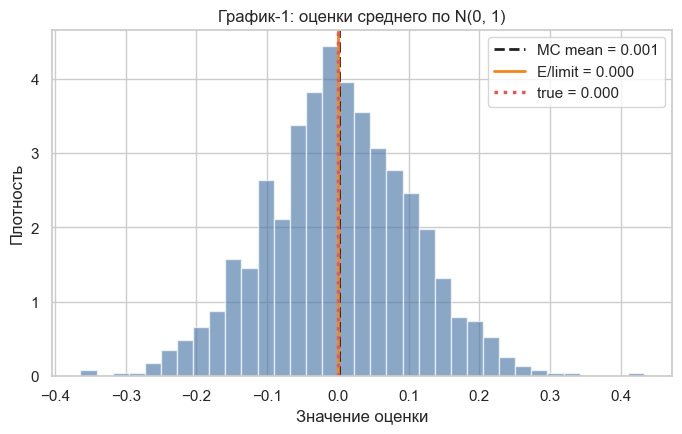

In [86]:
normal_mean_generator = lambda n: np.random.normal(loc=0, scale=1, size=n)
normal_mean_statistic = np.mean

normal_mean_estimates = simulate_estimates(
    normal_mean_generator,
    normal_mean_statistic,
    n=100,
    repeats=1000
)

plot_estimator_distribution(
    normal_mean_estimates,
    true_theta=0,
    expected_theta=0,
    title='График-1: оценки среднего по N(0, 1)'
)


---

Теперь ответы на вопросы из этого блока:
1. Потому что может быть маленький размер или изначальной выборки или маленькое число бутстрап подвыборок. У нас есть две сходимости: сходимость матожа оценки бутстрапа к истинной статистике и сходимость среднего оценок бутстрапа к матожу оценок бутстрапа. Поэтому маленький размер выборок на обеих стадиях может вести к фиговой сходимости
2. Как раз потому что у нас среднее оценок бутстрапа будет сходится к матожу при росте подвыборок бутстрапа, у нас общее смещение будет падать (но все еще будет ограничено размером первоначальной выьорки)



In [87]:
normal_mean_mc_means = simulate_mc_means(
    normal_mean_generator,
    normal_mean_statistic,
    n=100,
    repeats=1000,
    groups=50
)


<Axes: title={'center': 'График-2: распределение средних по MC-блокам'}, xlabel='Значение оценки', ylabel='Плотность'>

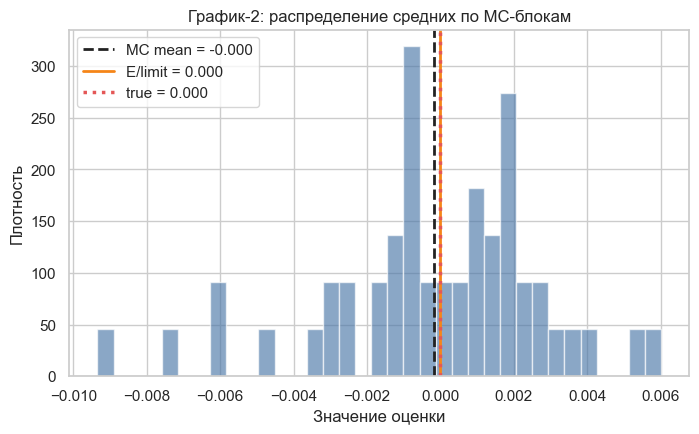

In [88]:
plot_estimator_distribution(
    normal_mean_mc_means,
    true_theta=0,
    expected_theta=0,
    title='График-2: распределение средних по MC-блокам'
)


---

Ответы на вопросы в этом блоке:

3. Мы берем K средних по бутстрап статистикам. Эти средние будут распределены нормально по ЦПТ: сумма статистик будет распределена нормально по ЦПТ (при достаточно большом B; у нас 1000), а дальше мы просто делим на константу (число подвыборок) – нормальность сохраняется

In [89]:
normal_mean_ci = normal_ci_for_mc_mean(normal_mean_estimates)
normal_mean_ci


array([-0.00549846,  0.00743219])

<Axes: title={'center': 'График-3: нормальный CI для MC-среднего'}, xlabel='Значение оценки', ylabel='Плотность'>

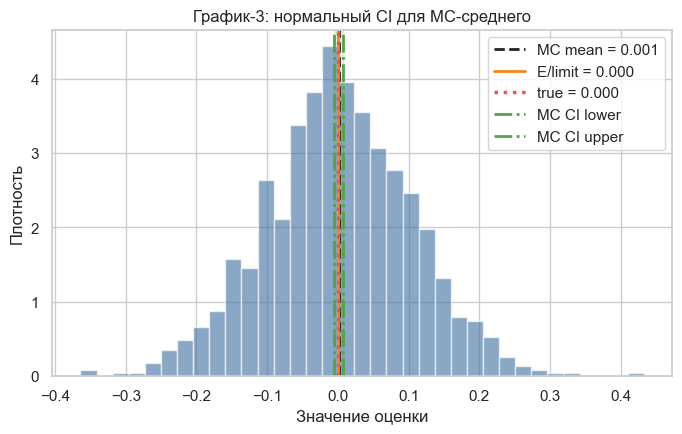

In [90]:
plot_estimator_distribution(
    normal_mean_estimates,
    true_theta=0,
    expected_theta=0,
    ci=normal_mean_ci,
    title='График-3: нормальный CI для MC-среднего'
)


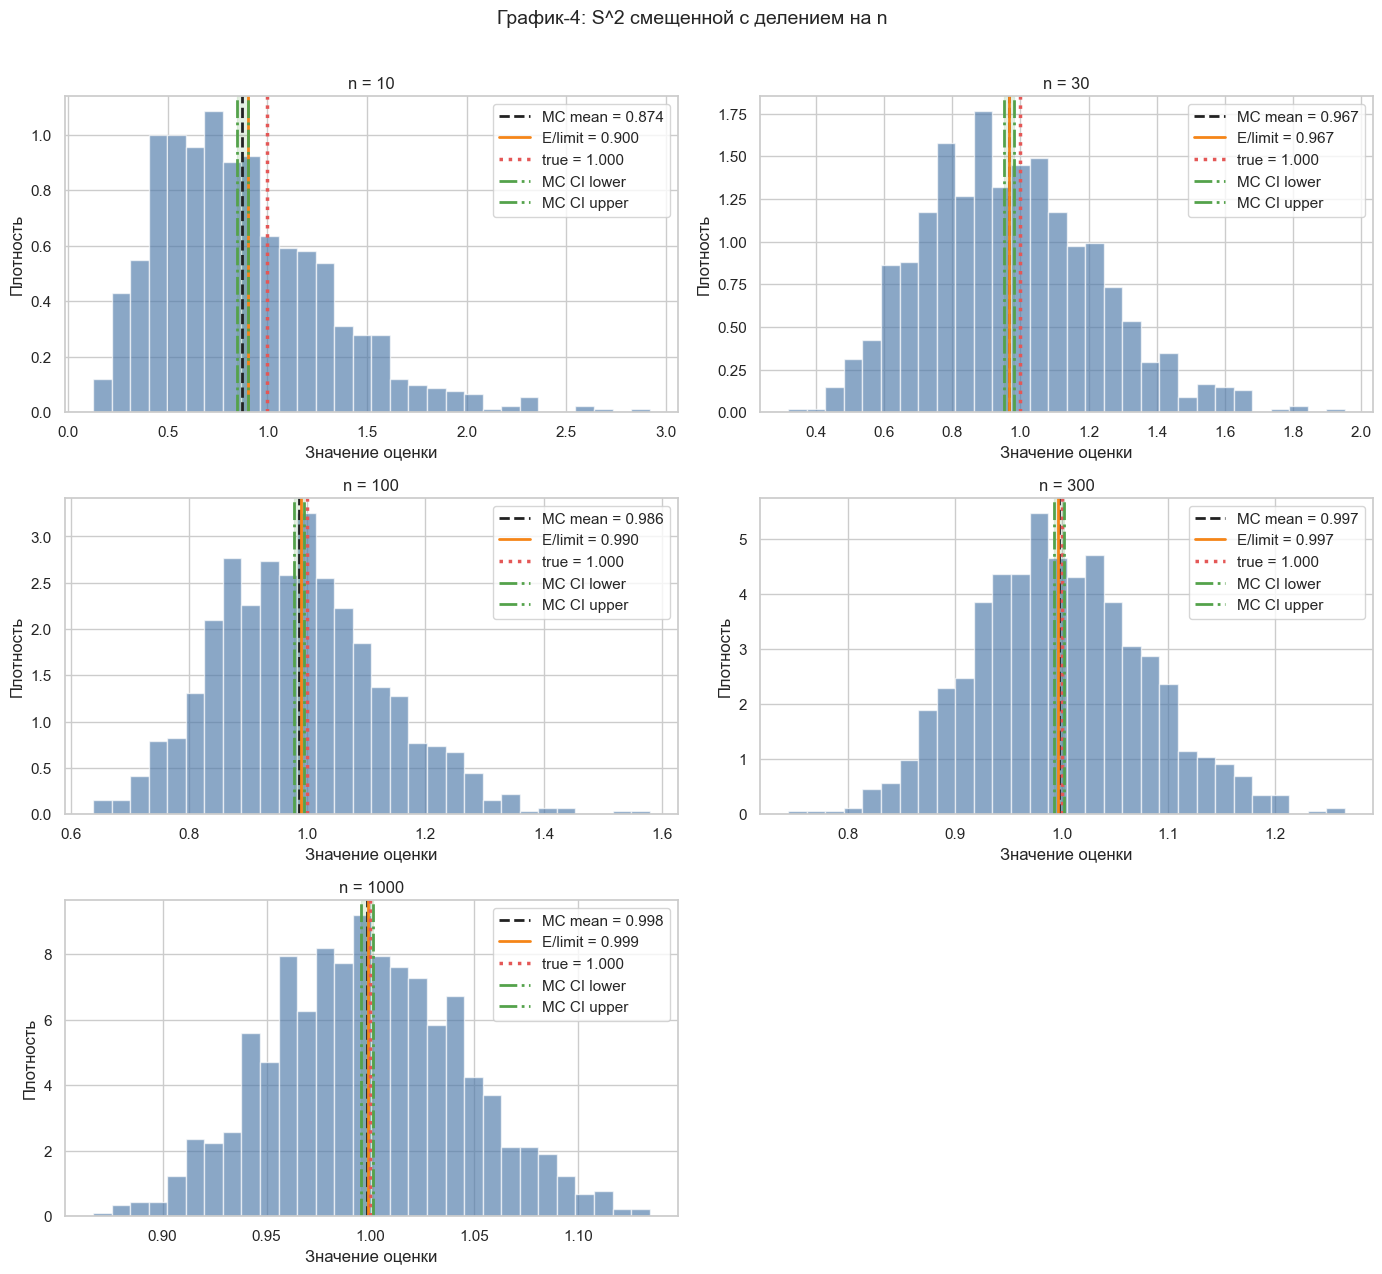

In [107]:
sample_sizes_unbiasedness = [10, 30, 100, 300, 1000]
standard_normal_generator = lambda n: np.random.normal(loc=0, scale=1, size=n)
biased_variance = lambda x: np.var(x, ddof=0)

plot_unbiasedness_by_n(
    standard_normal_generator,
    biased_variance,
    sample_sizes_unbiasedness,
    true_theta=1,
    expected_theta=lambda n: (n - 1) / n,
    repeats=1000,
    title='График-4: S^2 смещенной с делением на n'
)


### Проверка несмещенностей

1. $S^2_0 = \frac{1}{n}\sum(X_i-E(X))^2 $ $$E(S^2_0) = E(\frac{1}{n}\sum(X_i-E(X))^2) = \frac{1}{n}\sum E((X_i - \mu)^2) $$ По определению: \ $Var(X_i) = E((X_i - E(X_i))^2) \implies (S^2_0) \frac{1}{n}\sum Var(X_i) = \sigma^2 \implies\space $ несмещенная Из несмещенности следует асимптотическая несмещенность

2. $S^2 = \frac{1}{n} \sum (X_i - \bar{X})^2$

$$S^2 = \frac{1}{n} \sum (X_i - \bar{X})^2 = \frac{1}{n} \sum ((X_i - E(X)) - (\bar{X} - E(X)))^2 = \frac{1}{n}\sum(a - b)^2 = $$
$$= \frac{1}{n}\sum (a^2 - 2ab + b^2) = \frac{1}{n}\sum ((X_i - \mu)^2 - 2(X_i - \mu)(\bar{X} - E(X)) + (\bar{X} - \mu)^2) =$$
$$= \frac{1}{n}(\sum(X_i - \mu)^2 -2\sum(X_i-\mu)(\bar{X}-\mu) + \sum(\bar{X} - \mu)^2) =  $$
$$= \frac{1}{n}(\sum(X_i - \mu)^2 -2(\bar{X}-\mu)\sum(X_i-\mu) + \sum(\bar{X} - \mu)^2 =$$
$$= \frac{1}{n}(\sum(X_i - \mu)^2 -2(\bar{X}-\mu)(n\bar{X}-n\mu) + \sum(\bar{X} - \mu)^2  )$$
$$= \frac{1}{n}(\sum(X_i - \mu)^2 -2n(\bar{X}-\mu)^2 + \sum(\bar{X} - \mu)^2  )$$
$$= \frac{1}{n}(\sum(X_i - \mu)^2 -2n(\bar{X}-E(\bar{X}))^2 + \sum(\bar{X} - E(\bar{X}))^2) $$
$$= \frac{1}{n}(\sum(X_i - \mu)^2 -2n\cdot Var(\bar{X}) + n\cdot Var(\bar{X})) $$
$$= \frac{1}{n}\sum(X_i - \mu)^2 - Var(\bar{X}) = $$
$$= \sigma^2 - \frac{\sigma^2}{n} = \frac{n-1}{n}\sigma^2 != \sigma^2 \implies \text{оценка смещенная} $$ $$\text{При n}\to \infty: \frac{n-1}{n}\approx 1 \implies \frac{n-1}{n}\sigma^2 \approx \sigma^2 \implies \text{оценка будет асимптотически несмещенной} $$

3. $X_{(1)}$

Тк у нас распределеие непрерывное, то значение в точке равно нулю: $P(X_i = A) = 0\space$ для любого i

Тогда минимум выборки тоже будет всегда больше A, просто потому что получить A нельзя (ну почти), а любое другое значение будет больше, тк A – минимум. Поэтому первая порядковая статистика будет завыщшать фактическую статистику

4. Среднее опросное
---
1. ${\hat{\mu_1}}$
$$
\hat{\mu}_1 = \overline{Y}
$$
Поскольку
$$
Y_i = X_iD_i\space \text{и} \space X_i ; D_i \space \text{независимы, получаем}:
$$
$$
E(Y_i) = E(X_iD_i) = E(X_i)E(D_i)
$$

Так как

$$
E(X_i) = \mu, \qquad E(D_i) = p
$$

то

$$
E(Y_i) = p\mu
$$

Следовательно,

$$
E(\overline{Y}) = p\mu
$$

То есть:$\quad E(\hat{\mu}_1) = p\mu \implies\space$ смещенная и асимптотически смещенная

2. Вторая оценка очень странная не знаю. Во первых странно Y_i=0, хотя это то же самое, что и D_i (ну плюс минус изза непрерывности распределения). Но что более странно, что мы делим на 1-p а не на p, хотя как я понял мы хотели восстановить несмещенность, исправив прошлую оценку. Если бы мы делили на p, то как раз исправили бы ее. А так – нет



Второе распределение просто моделирует мир, в котором вероятность недовольного пользователя дать отзыв выше, чем у довольного. То есть модель неслуайного отказа от ответа (что абсолютно логично в реальном мире)

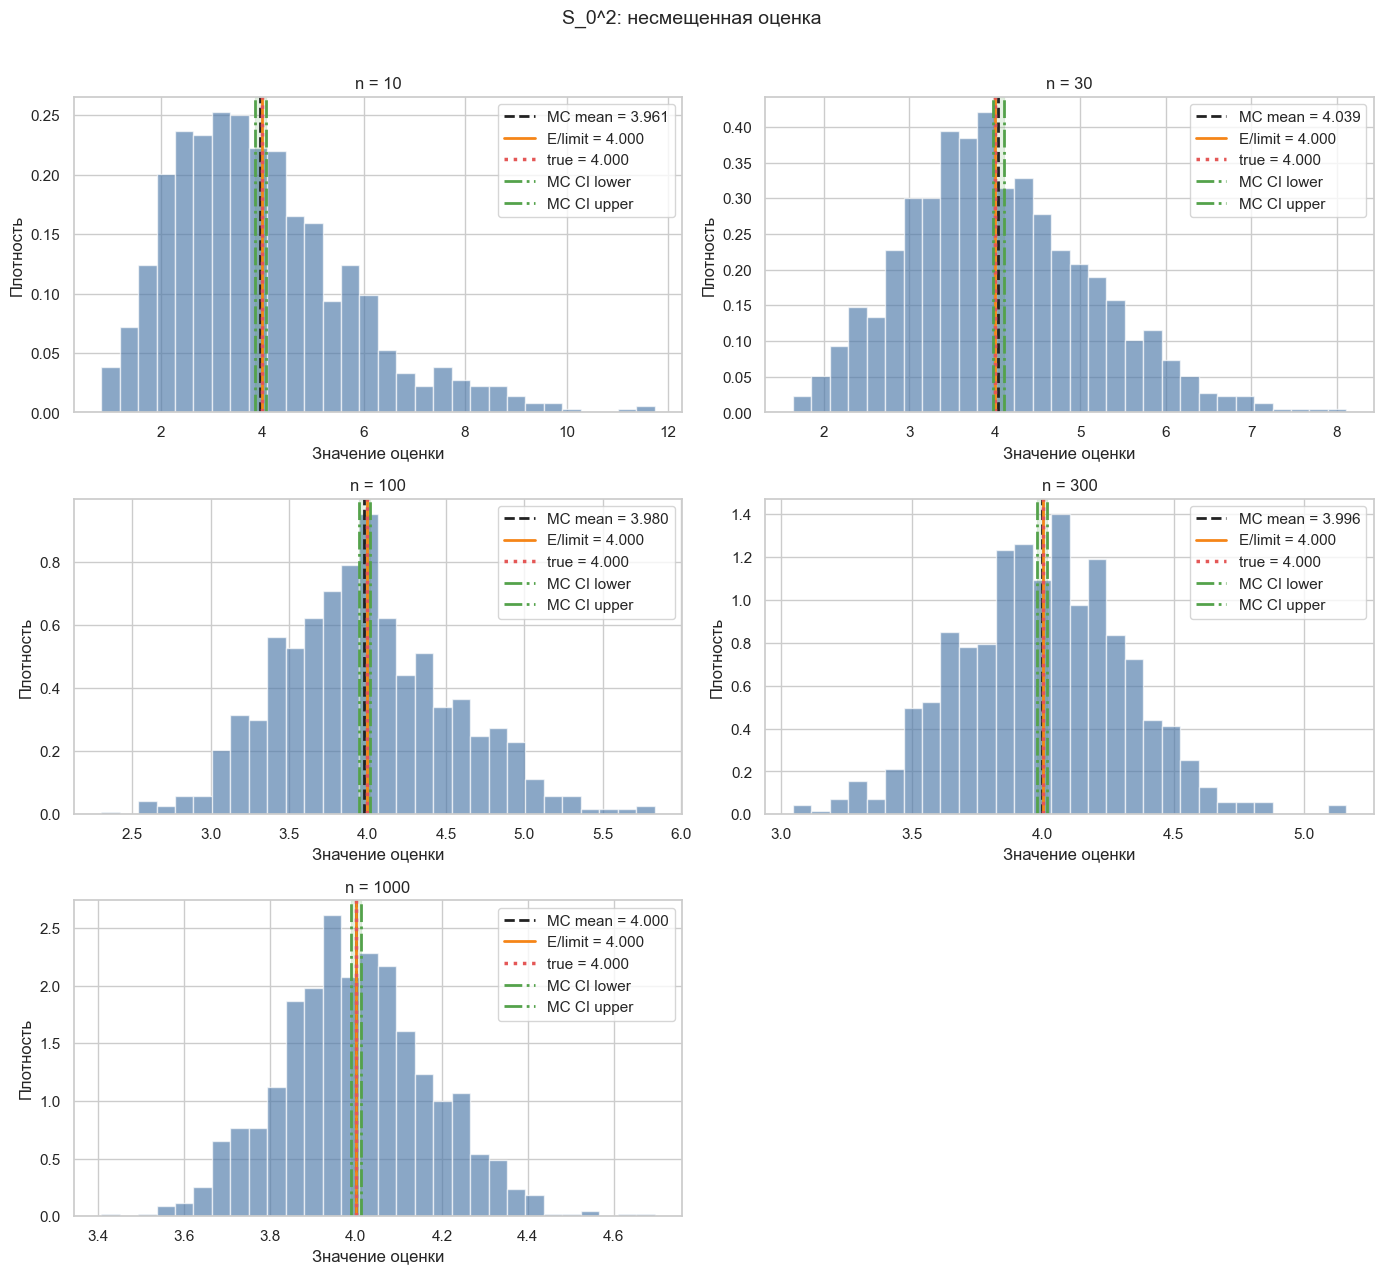

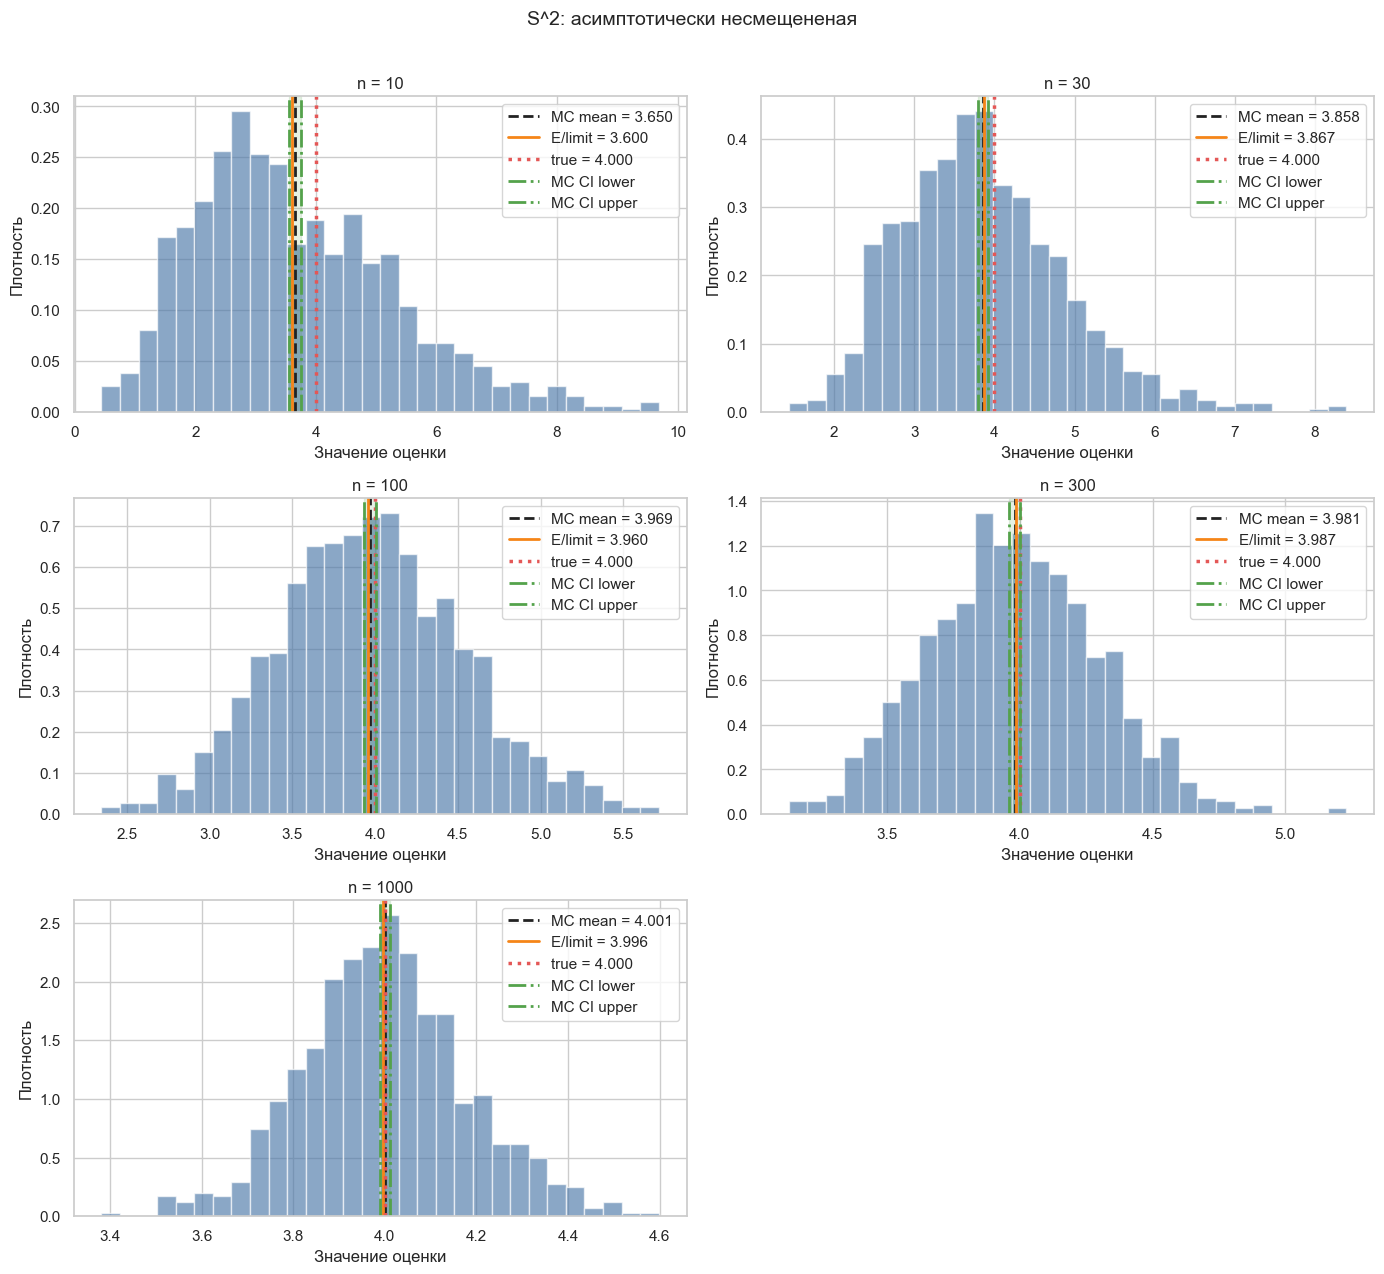

In [119]:
mu = 67
sigma = 2
true_variance = sigma ** 2
normal_sample_sizes = [10, 30, 100, 300, 1000]

normal_generator = lambda n: np.random.normal(loc=mu, scale=sigma, size=n)
s2_known_mean = lambda x: np.mean((x - mu) ** 2)
s2_sample_mean = lambda x: np.mean((x - np.mean(x)) ** 2)

plot_unbiasedness_by_n(
    normal_generator,
    s2_known_mean,
    normal_sample_sizes,
    true_theta=true_variance,
    expected_theta=true_variance,
    repeats=1000,
    title='S_0^2: несмещенная оценка'
)

plot_unbiasedness_by_n(
    normal_generator,
    s2_sample_mean,
    normal_sample_sizes,
    true_theta=true_variance,
    expected_theta=lambda n: (n - 1) / n * true_variance,
    repeats=1000,
    title='S^2: асимптотически несмещененая'
)


Видим, что оценка действительно сначала смещена, но с ростом n все больше и больше приближается к истинному значению

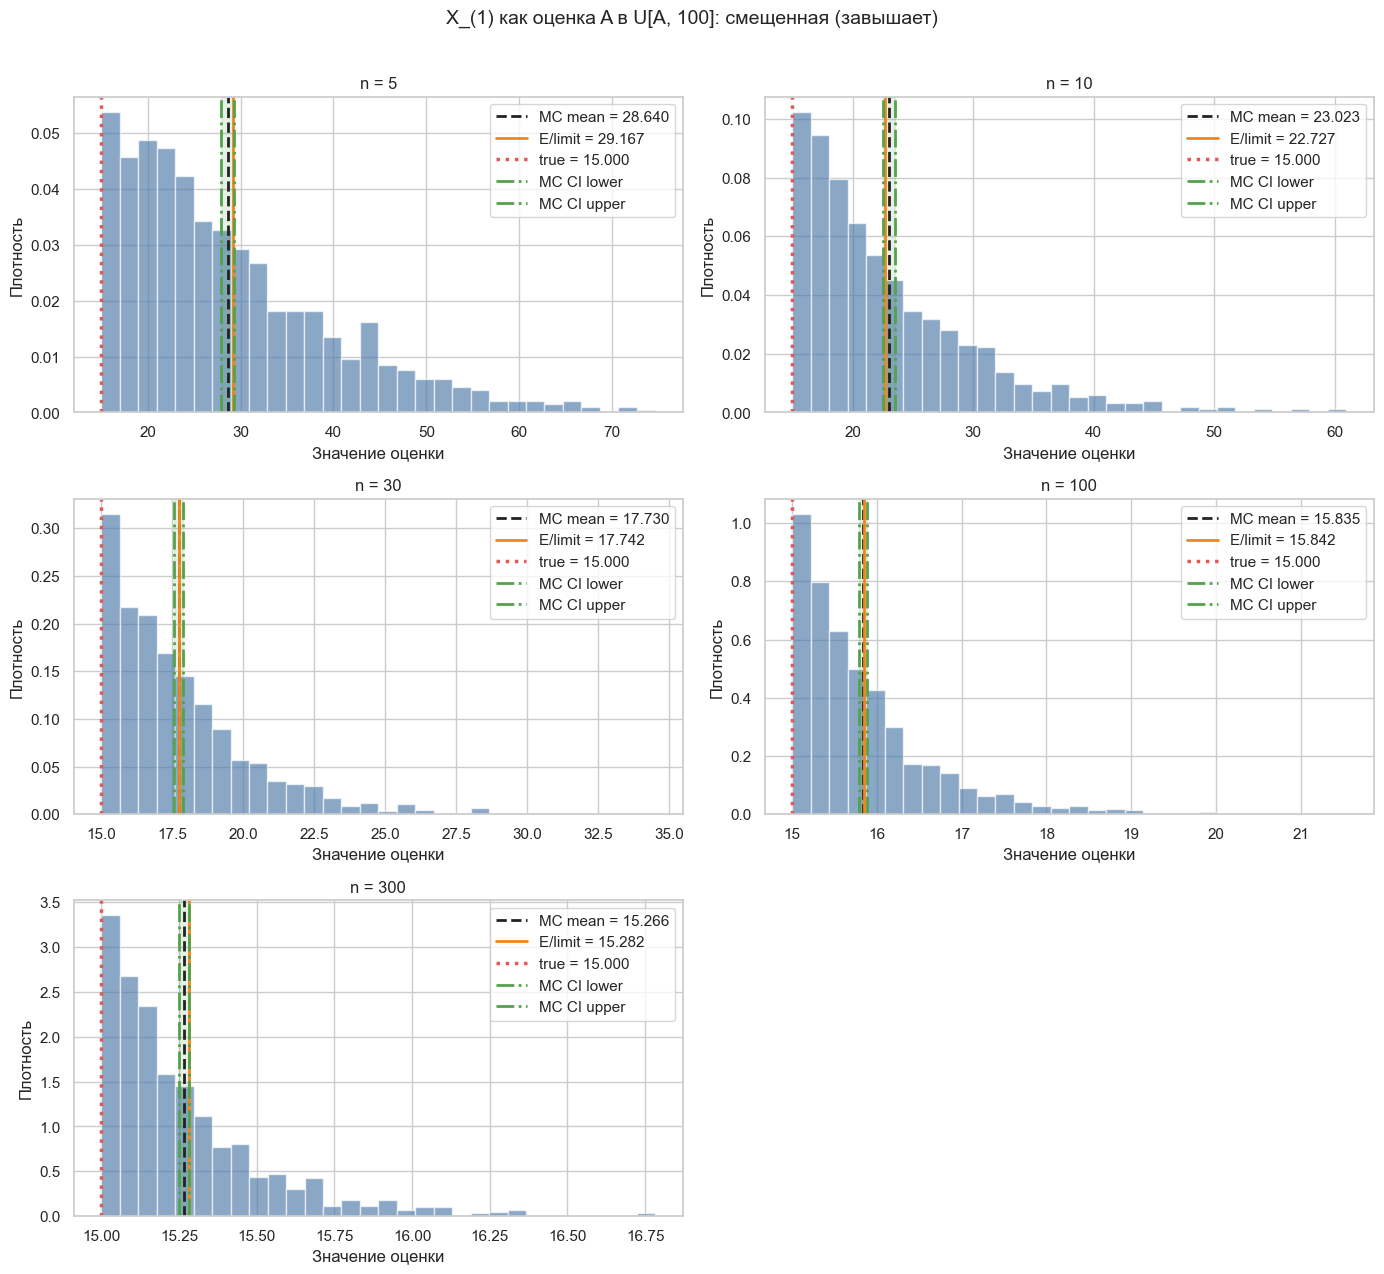

In [120]:
left_a = 15
right_b = 100
uniform_sample_sizes = [5, 10, 30, 100, 300]

uniform_generator = lambda n: np.random.uniform(left_a, right_b, size=n)
minimum_statistic = np.min
minimum_expected = lambda n: left_a + (right_b - left_a) / (n + 1)

plot_unbiasedness_by_n(
    uniform_generator,
    minimum_statistic,
    uniform_sample_sizes,
    true_theta=left_a,
    expected_theta=minimum_expected,
    repeats=1000,
    title='X_(1) как оценка A в U[A, 100]: смещенная (завышает)'
)


Видим, что оценка смещена

In [94]:
survey_mu_2 = lambda y_values: np.mean(y_values) / np.mean(y_values == 0)


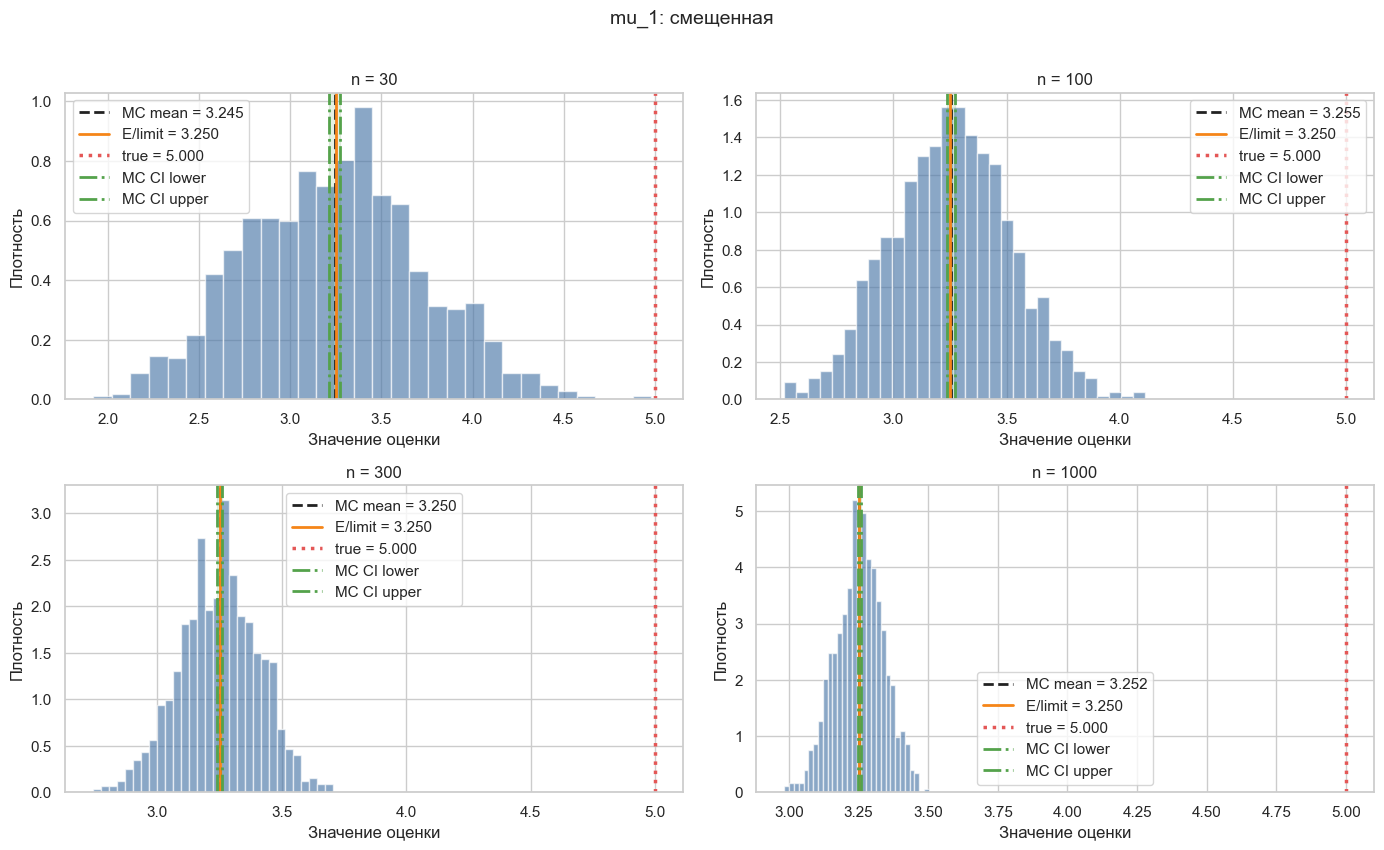

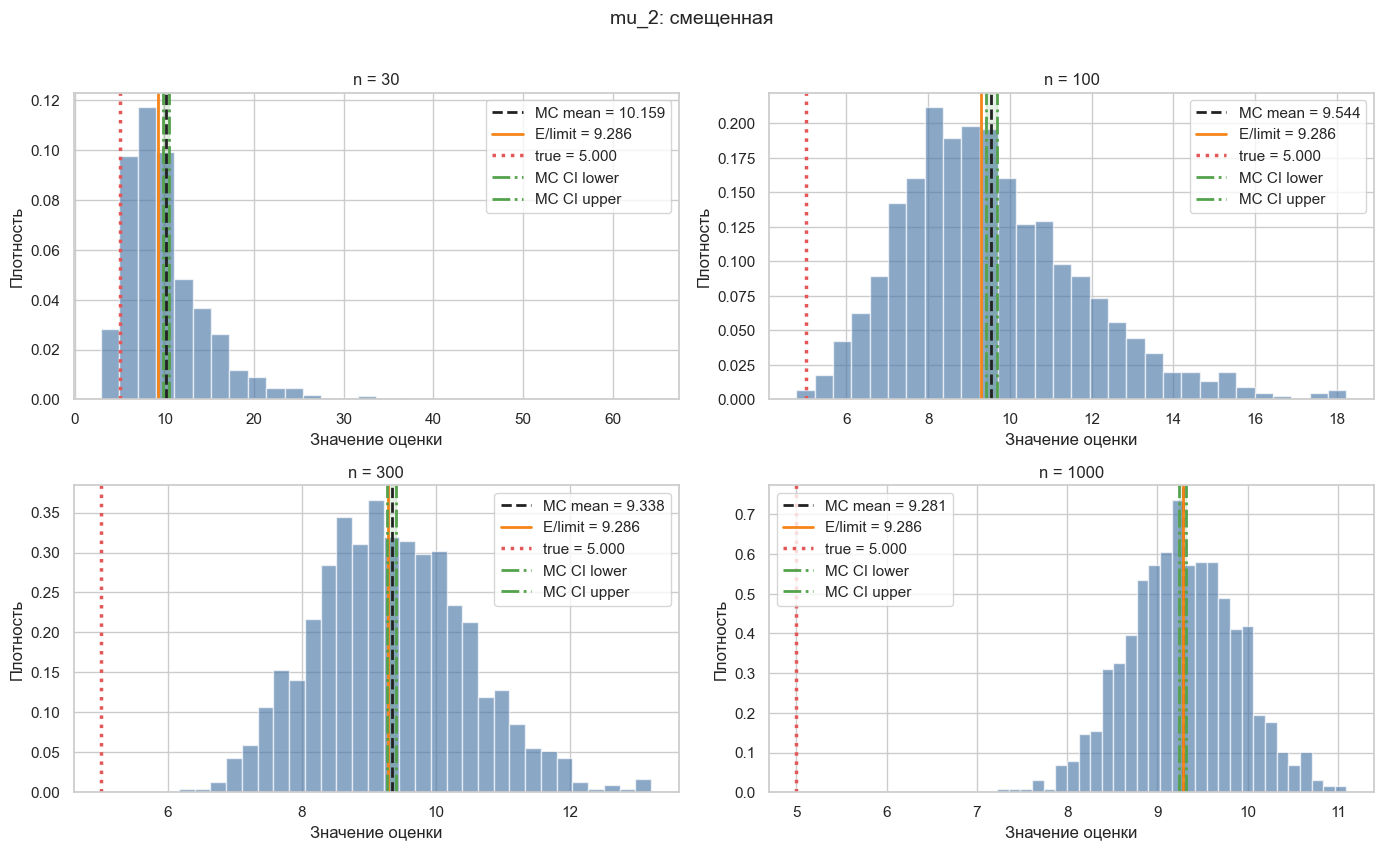

In [121]:
survey_mu = 5
survey_sigma = 1.5
survey_p_answer = 0.65
survey_sample_sizes = [30, 100, 300, 1000]

survey_independent_generator = lambda n: (
    np.random.normal(loc=survey_mu, scale=survey_sigma, size=n)
    * np.random.binomial(1, survey_p_answer, size=n)
)

plot_unbiasedness_by_n(
    survey_independent_generator,
    np.mean,
    survey_sample_sizes,
    true_theta=survey_mu,
    expected_theta=survey_mu * survey_p_answer,
    repeats=1000,
    title='mu_1: смещенная'
)

plot_unbiasedness_by_n(
    survey_independent_generator,
    survey_mu_2,
    survey_sample_sizes,
    true_theta=survey_mu,
    expected_theta=survey_mu * survey_p_answer / (1 - survey_p_answer),
    repeats=1000,
    title='mu_2: смещенная'
)


Видим, что обе оценки сильно смещены относительно истинного значения и даже при росте n разница не становится меньше

## Состоятельность


### Разработка графика

<span style="color: #AC19C9;">Все идеи графиков, выделенные вот так, необходимо имплементировать. На все вопросы, отмеченные так, необходимо ответить.</span>

Здесь нам необходимо продемонстрировать определение: $P(|\hat{\theta}_n- \theta| \geq \varepsilon|) \xrightarrow{n\rightarrow\infty} 0 \quad \forall \varepsilon > 0$

Если записать его чуть формальнее, то:

$\forall \varepsilon > 0 \quad \forall \epsilon > 0 \quad \exists N : \quad \forall n \geq N \quad P(|\hat{\theta}_n- \theta| \geq \varepsilon|) < \epsilon$

То есть, какую бы точность для предела ($\epsilon$) и для отклонений ($\varepsilon$) мы не зафиксировали, все равно найдётся такой размер выборки $N$, начиная с которого вероятность для события "отличие между статистикой и параметром ($|\hat{\theta}_n- \theta|$) вылезло за эту границу точности для оценки" (то есть случилось $|\hat{\theta}_n- \theta| > \varepsilon$) меньше, чем допустимая граница предела ($\epsilon$).

Очевидно, нам фактически нужно показать динамику этой вероятности в зависимости от n.

Для этого снова воспользуемся бутстрапом.

Зафиксируем размер выборки n. Возьмем множество из B выборок такого размера из распределения X, посчитаем статистику $\hat{\theta}(X_1, \dotso, X_n)$ для каждой выборки, получим ее эмпирическое распределение размера B. Для этого эмпирического распределения, зная истинный параметр $\theta$, мы можем с вами получить оценку вероятности того, что мы ошиблись сильнее чем на какой-то фиксированный $\varepsilon$: это буквально доля наших оценок из эмпирического распределения, которые ошибаются так или сильнее: 

$\widehat{P(|\hat{\theta}_n- \theta| > \varepsilon)} = \frac{1}{B} \sum_{i=1}^B \mathcal{I}(|\hat{\theta}_{n, i} - \theta| > \varepsilon)$

(Напомним, что если А это некоторое случайное событие, то $\mathcal{I}(A)$ это индикаторная случайная величина, которая равна 1, если А произошло, и 0 иначе. В нашем случае, событие А это "оценка по i-й выборке ошиблась сильнее чем на $\varepsilon$". То есть наша сумма по индикаторам равна числу оценок, с которыми такое случилось).


Тогда на одном графике можно отразить эмпирическое распределение оценок и истинное значение параметра, далее при помощи линий отделить "критические области", в которых отклонение от истины сильнее заданного $\varepsilon$, и подписать долю оценок, которые в эти области попали.

Далее это отображение можно повторять для увеличивающихся n, сэмплируя новые выборки большего размера, и показывать, что для фиксированного $\varepsilon$ вероятность вылететь за него действительно снижается с ростом выборки! (Это будет видно и в простых подписях и числе точек / объёме хвостов за границами, но для явности стоит рядом вывести простой лайнплот оцениваемых вероятностей).

А следующим шагом можно добавить на каждый график при фиксированном n несколько границ точности $\varepsilon$: так мы покажем свойство "для любых границ точности". Для каждого такого $\varepsilon$ понадобится свой лайнплот, поскольку он явно зашит в "вероятность сильного отклонения", которая на нем отражена. При этом на этом графике вы будете неявно видеть и $N(\epsilon)$: это будет размер выборки, начиная с которого вероятность отклонения (то есть точка на графике) не выше $\epsilon$.


Хм, а как отрисовать этот график, если оценка несостоятельная?
- Фактически, у нас всё остается тем же самым, и все графики вам явно покажут, что сходимости нет: число точек / области за границами будут всё расти, как и вероятность сильного отклонения.


Хм, а если параметр бесконечный, например, как дисперсия или математическое ожидание некоторых распределений?
- Тогда мы не можем отобразить ни линию истинного параметра, ни границы отклонения. Достаточно будет показать, как изменяются эмпирические распределения оценок с ростом n. Этого можно добиться, если сделать все параметры выше опциональными при отрисовке, и управлять ими через kwargs функции.


<span style="color: #AC19C9;">Это целостная идея системы графиков, ее необходимо имплементировать так, чтобы все свойства, описанные в заметке, было хорошо видно.</span>





### Применение для конкретных оценок

<span style="color: #AC19C9;">Для всех оценок ниже необходимо отобразить эксперименты на имплементированных графиках, прокомментировать, как теория соотносится с эмпирикой, и где именно на графике это видно.</span> 

Доказывать состоятельность нужно не везде.


#### Самое обычное среднее

Пусть $(X_1 \dotso X_n)$ - i. i. d. выборка из геометрического распределения (параметр выберите сами).


Наша статистика -- обыкновенное советское среднее $\overline{X}$.

<span style="color: #AC19C9;">
Проверьте теоретически состоятельность этой оценки. Отобразите её поведение на имплементированных графиках, прокомментируйте, как теория соотносится с экспериментами, и где именно на графиках это видно.
</span>


Никаких подвохов, честное слово, это просто вводный пункт.


#### $X_{(1)}$ как оценка A в U[A; 100]


Пусть $(X_1 \dotso X_n)$ - i. i. d. выборка из распределения $U[A; 100]$.

$X_{(1)} = min_{i} \{X_1 \dotso X_n\}$, первая порядковая статистика.


Проверим теперь эту оценку на состоятельность. Доказывать состоятельность здесь не требуется, можно только провести эксперимент. 

<span style="color: #AC19C9;">
Отобразите поведение оценки на имплементированных графиках. Прокомментируйте, является ли эта оценка состоятельной, что именно на графиках на это указывает?
</span>


#### Простое дискретное распределение

Пусть $(X_1 \dotso X_n)$ - i. i. d. выборка из дискретного распределения, заданного таблицей:

|$X(\omega)$ |                -3 |         0 |        2 |
|------------|-------------------|-----------|----------|
|$P(X = ...)$|$\frac23 - \theta$ | $\frac13$ | $\theta$ |


И дана оценка $\hat{\theta} = \frac{\overline{X}}{5}$.

Докажите, что эта оценка является несостоятельной.

Графики отобразите и для этой оценки, и для её исправленной версии, сравните их между собой.


<span style="color: #AC19C9;">
Докажите, что эта оценка является несостоятельной, и исправьте ее так, чтобы она стала состоятельной. Отобразите поведение обеих оценок (исправленной и неисправленной) на имплементированных графиках. Как на графиках отражаются свойства этих оценок, чем именно их графики отличаются и почему?
</span>

#### Оценка дисперсии шума в MA(2)

Пусть у нас есть гауссовский случайный процесс MA(2):

$X_t = \mu + \varepsilon_t + \beta_1 \cdot \varepsilon_{t-1} + \beta_2 \cdot \varepsilon_{t-2}$

где 

$\mu, \beta_1, \beta_2$ - некоторые *ненулевые* константы (вы можете выбрать их сами)

$\varepsilon_i \sim \mathcal{N}(0; \sigma^2_\varepsilon)$, и все $\varepsilon_i$ независимы в совокупности.



Мы наблюдаем только выборку из X: $(X_1 \dotso X_t \dotso X_T)$. В этом случае "выборка" из это наблюдаемая траектория процесса, то есть одна реализация нашего процесса во временной ряд в реальности. Соседние наблюдения в ней очевидно зависимы через общие шумы $\varepsilon$.

Попытаемся по наблюдаемому ряду оценить дисперсию именно шума, предполагая, что они описываются именно MA(2) процессом с известными нам всеми коэффициентами, кроме собственно $\sigma^2_\varepsilon$.

<span style="color: #AC19C9;">Воспользуйтесь методом моментов и выразите через</span> $D(X_t)$ <span style="color: #AC19C9;">саму</span> $\sigma^2_\varepsilon$. <span style="color: #AC19C9;">Предложите на её основе состоятельную оценку. Отобразите поведение оценки на имплементированных графиках. Прокомментируйте, что на графиках указывает на то, что она состоятельна?</span> 

Состоятельность оценки можно просто продемонстрировать на графиках и не доказывать.




#### и тут пришел Коши.


Пусть $(X_1 \dotso X_n)$ - i. i. d. выборка из стандартного распределения Коши.

Наша статистика -- $\overline{X}$. 


<span style="color: #AC19C9;">
Отобразите поведение оценки на имплементированных графиках. Прокомментируйте, что вы наблюдаете на графиках, почему это происходит?
</span>








In [97]:
def plot_consistency_distributions(
    estimates_by_n: dict[int, np.ndarray],
    *,
    true_theta: float | None = None,
    epsilons: list[float] | None = None,
    title: str = '',
    bins: int = 35,
    trim: tuple[float, float] | None = None
) -> None:
    sample_sizes = list(estimates_by_n.keys())
    cols = min(3, len(sample_sizes))
    rows = int(np.ceil(len(sample_sizes) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 3.8 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, n in zip(axes, sample_sizes):
        estimates = estimates_by_n[n]
        values_to_draw = estimates
        trim_limits = None
        if trim is not None and len(estimates) > 0:
            left, right = np.quantile(estimates, trim)
            trim_limits = (left, right)
            values_to_draw = estimates[(estimates >= left) & (estimates <= right)]

        ax.hist(values_to_draw, bins=bins, density=True, alpha=0.65, color='#4c78a8')
        ax.axvline(np.mean(estimates), color='#222222', linestyle='--', linewidth=2, label='MC mean')

        if true_theta is not None:
            ax.axvline(true_theta, color='#e45756', linestyle=':', linewidth=2.5, label='true')
            for epsilon in epsilons or []:
                ax.axvline(true_theta - epsilon, color='#f58518', linestyle='-.', linewidth=1.5)
                ax.axvline(true_theta + epsilon, color='#f58518', linestyle='-.', linewidth=1.5)

            prob_text = []
            for epsilon in epsilons or []:
                probability = np.mean(np.abs(estimates - true_theta) >= epsilon)
                prob_text.append(f'eps={epsilon}: {probability:.3f}')
            if prob_text:
                ax.text(
                    0.02,
                    0.98,
                    '\n'.join(prob_text),
                    transform=ax.transAxes,
                    va='top',
                    ha='left',
                    fontsize=9,
                    bbox={'facecolor': 'white', 'alpha': 0.75, 'edgecolor': 'none'}
                )

        if trim_limits is not None:
            ax.set_xlim(trim_limits)

        ax.set_title(f'n = {n}')
        ax.set_xlabel('Значение оценки')
        ax.set_ylabel('Плотность')
        ax.legend()

    for ax in axes[len(sample_sizes):]:
        ax.axis('off')

    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_consistency_check(
    sample_generator: Callable[[int], np.ndarray],
    statistic: Callable[[np.ndarray], float],
    sample_sizes: list[int],
    *,
    true_theta: float | None = None,
    epsilons: list[float] | None = None,
    repeats: int = 1000,
    title: str = '',
    trim: tuple[float, float] | None = None
) -> None:
    estimates_by_n = {}
    for n in sample_sizes:
        estimates_by_n[n] = simulate_estimates(
            sample_generator,
            statistic,
            n,
            repeats=repeats
        )

    plot_consistency_distributions(
        estimates_by_n,
        true_theta=true_theta,
        epsilons=epsilons,
        title=title,
        trim=trim
    )

    if true_theta is not None and epsilons is not None:
        rows = []
        for n, estimates in estimates_by_n.items():
            for epsilon in epsilons:
                rows.append({
                    'n': n,
                    'epsilon': epsilon,
                    'probability': np.mean(np.abs(estimates - true_theta) >= epsilon)
                })
        table = pd.DataFrame(rows)

        fig, ax = plt.subplots(figsize=(8, 4.5))
        for epsilon in sorted(table['epsilon'].unique()):
            part = table[table['epsilon'] == epsilon]
            ax.plot(part['n'], part['probability'], marker='o', label=f'eps = {epsilon}')
        ax.set_xscale('log')
        ax.set_ylim(-0.03, 1.03)
        ax.set_xlabel('n')
        ax.set_ylabel('MC P(|оценка - theta| >= eps)')
        ax.set_title(title + ': вероятность сильного отклонения')
        ax.legend()
        plt.show()


### Исследование состоятельности

1. $\bar{X}$
$$\text{По неравенству Чебышева:} \space P(|X - E(X)| \ge \varepsilon) \le\frac{Var(X)}{\varepsilon^2} $$
$$ P(|\bar{X} - E(\bar{X})| \ge \varepsilon) \le\frac{Var(\bar{X})}{\varepsilon^2} $$
$$E(\bar{X}) = E(X) \implies P(|\bar{X} - E(\bar{X})| \ge \varepsilon) = P(|\bar{X} - E(X)| \ge \varepsilon) \le \frac{Var(\bar{X})}{\varepsilon^2}$$
$$Var(\bar{X}) = \frac{1}{n}Var(X) \implies n\to_\infty Var(\bar{X})  \to 0$$
$$\implies P(|\bar{X} - E(X)| \ge \varepsilon) \to_{n\to\infty} 0$$
$$\implies \text{оценка состоятельна} $$


3. $\hat{\theta} = \frac{\bar{X}}{5}$ 
$$\text{По ЗБЧ среднее является состоятельной оценкой матожа. Найдем матож:}$$
$$E(X) = -3(\frac{2}{3}-\theta)+0\cdot\frac{1}{3} + 2\theta = 5\theta-2 $$
$$\bar{X}\xrightarrow{P}E(X) \implies \hat{\theta} = \frac{\bar{X}}{5} \xrightarrow{P} \frac{E(X)}{5} $$
$$\hat{\theta} = \frac{\bar{X}}{5}\xrightarrow{P}\frac{5\theta - 2}{5} = \theta - \frac{2}{5}\implies\text{Видим, что оценка сходится не к}\space \theta\space\text{, а к}\space \theta - \frac{2}{5}\space\text{, а значит несостоятельна} $$
$$\text{Чтобы исправить ее, нужно просто добавить}\space \frac{2}{5}: \hat{\theta} = \frac{\bar{X}}{5}+\frac{2}{5} $$

4. Пампарам
$$D(X_t) = D(\mu + \varepsilon_t + \beta_1\varepsilon_{t-1} + \beta_2\varepsilon_{t-2}) = D(\varepsilon_t) + \beta_1^2D(\varepsilon_{t-1}) + \beta_2^2D(\varepsilon_{t-2}) = $$ $$ = \sigma^2_\varepsilon + \beta_1^2\sigma^2_\varepsilon + \beta_2^2\sigma^2_\varepsilon \implies \sigma^2_\varepsilon = \frac{D(X_t)}{1 + \beta_1^2+\beta_2^2} $$
$$\implies \hat{\sigma}^2_\varepsilon = \frac{\hat{D}(X_t)}{1 + \beta_1^2+\beta_2^2} $$
$$\text{Используем состоятельную оценку дисперсии:} \quad\hat{D}(X_t) = \frac{1}{T}\sum(X_t - \mu)^2 $$
$$\implies \hat{\sigma}^2_\varepsilon = \frac{1}{1 + \beta_1^2+\beta_2^2}\cdot\frac{1}{T}\sum(X_t - \mu)^2 $$

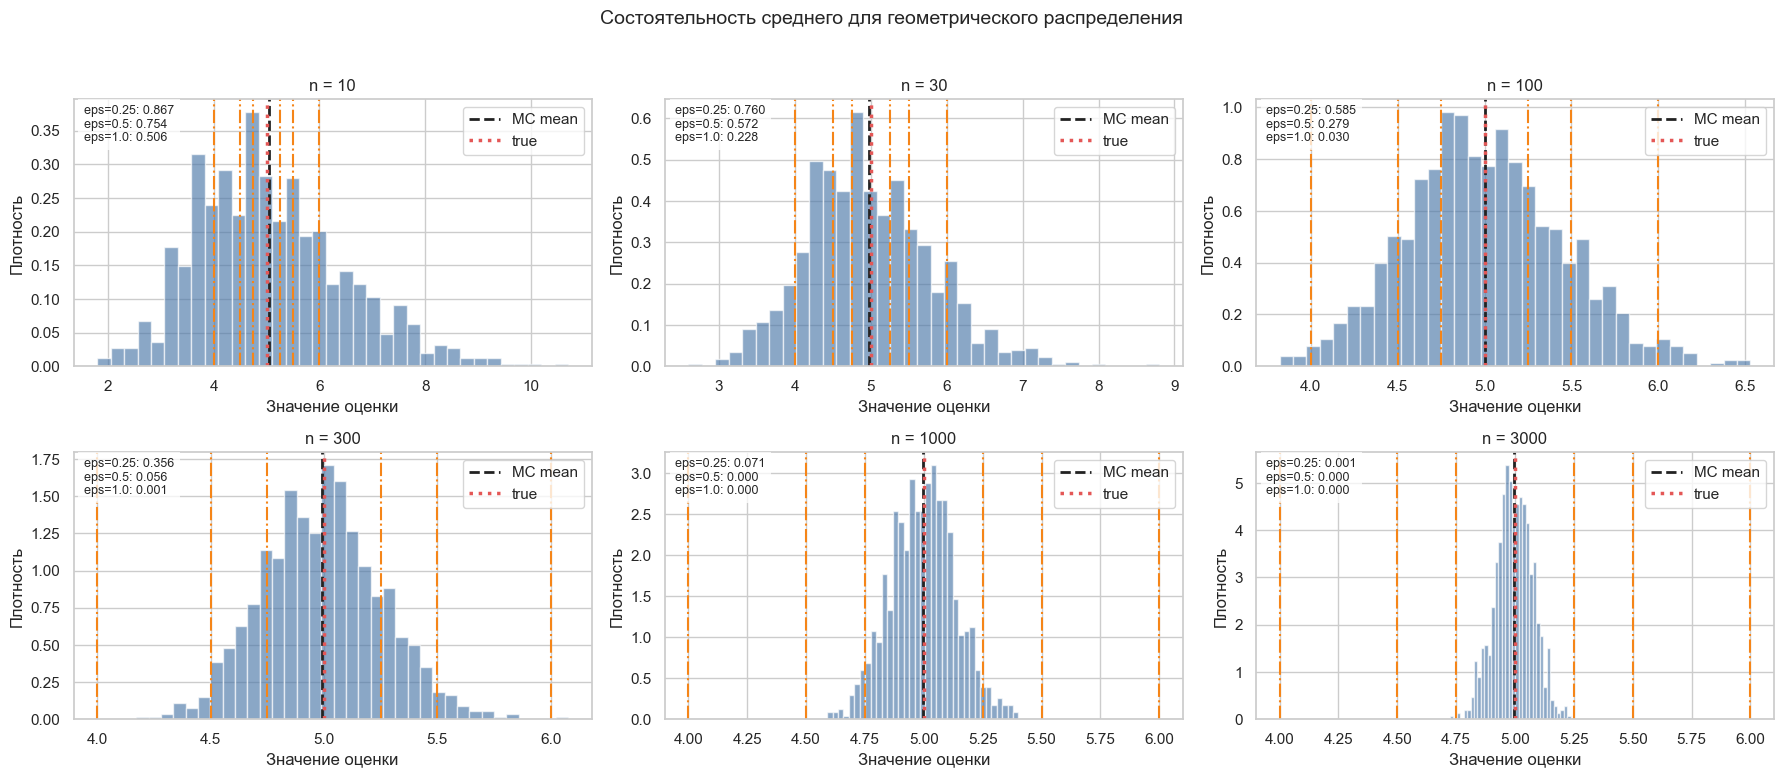

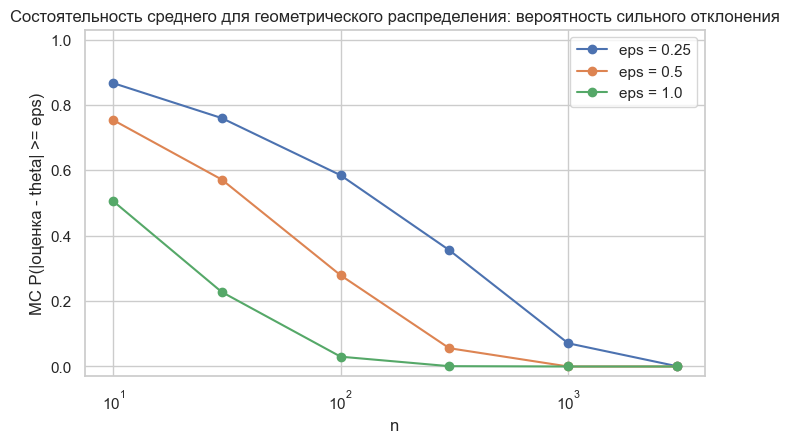

In [98]:
consistency_sample_sizes = [10, 30, 100, 300, 1000, 3000]

geometric_p = 0.2
geometric_generator = lambda n: np.random.geometric(p=geometric_p, size=n)
geometric_mean = lambda x: np.mean(x)

plot_consistency_check(
    geometric_generator,
    geometric_mean,
    consistency_sample_sizes,
    true_theta=1 / geometric_p,
    epsilons=[0.25, 0.5, 1.0],
    repeats=1000,
    title='Состоятельность среднего для геометрического распределения'
)


Видим, что оценка действительно состоятельна: при росте n распределение оценок все более и более съезжает к истинному значению (а вероятность получить большую по модулю разность падает до 0)

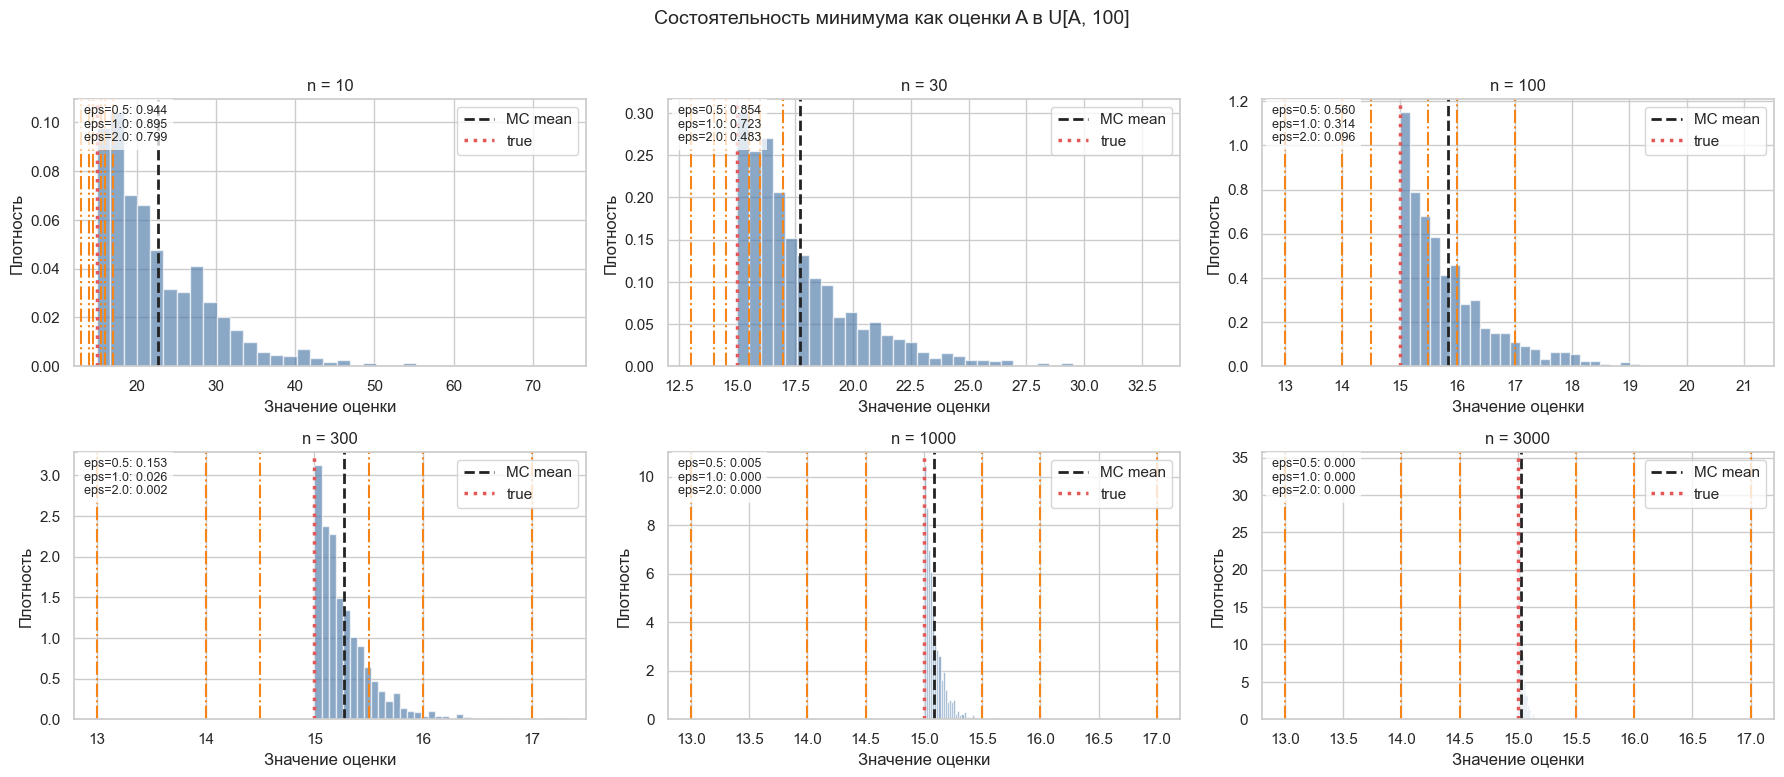

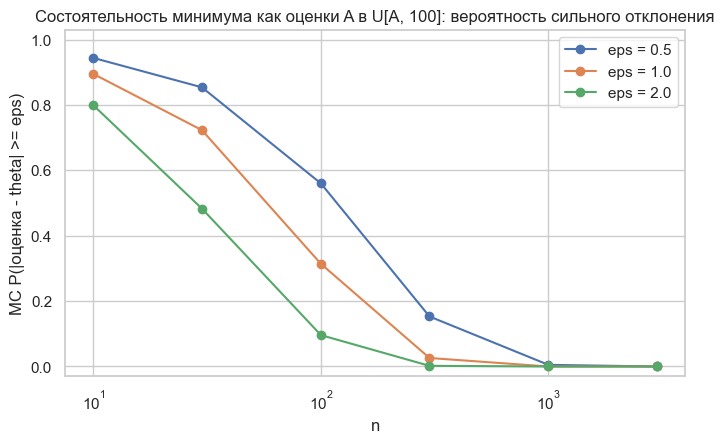

In [99]:
consistent_left_a = 15
consistent_right_b = 100
uniform_consistency_generator = lambda n: np.random.uniform(consistent_left_a, consistent_right_b, size=n)

plot_consistency_check(
    uniform_consistency_generator,
    np.min,
    consistency_sample_sizes,
    true_theta=consistent_left_a,
    epsilons=[0.5, 1.0, 2.0],
    repeats=1000,
    title='Состоятельность минимума как оценки A в U[A, 100]'
)


Видим, что оценка действительно состоятельна: при росте n распределение оценок все более и более съезжает к истинному значению (а вероятность получить большую по модулю разность падает до 0)

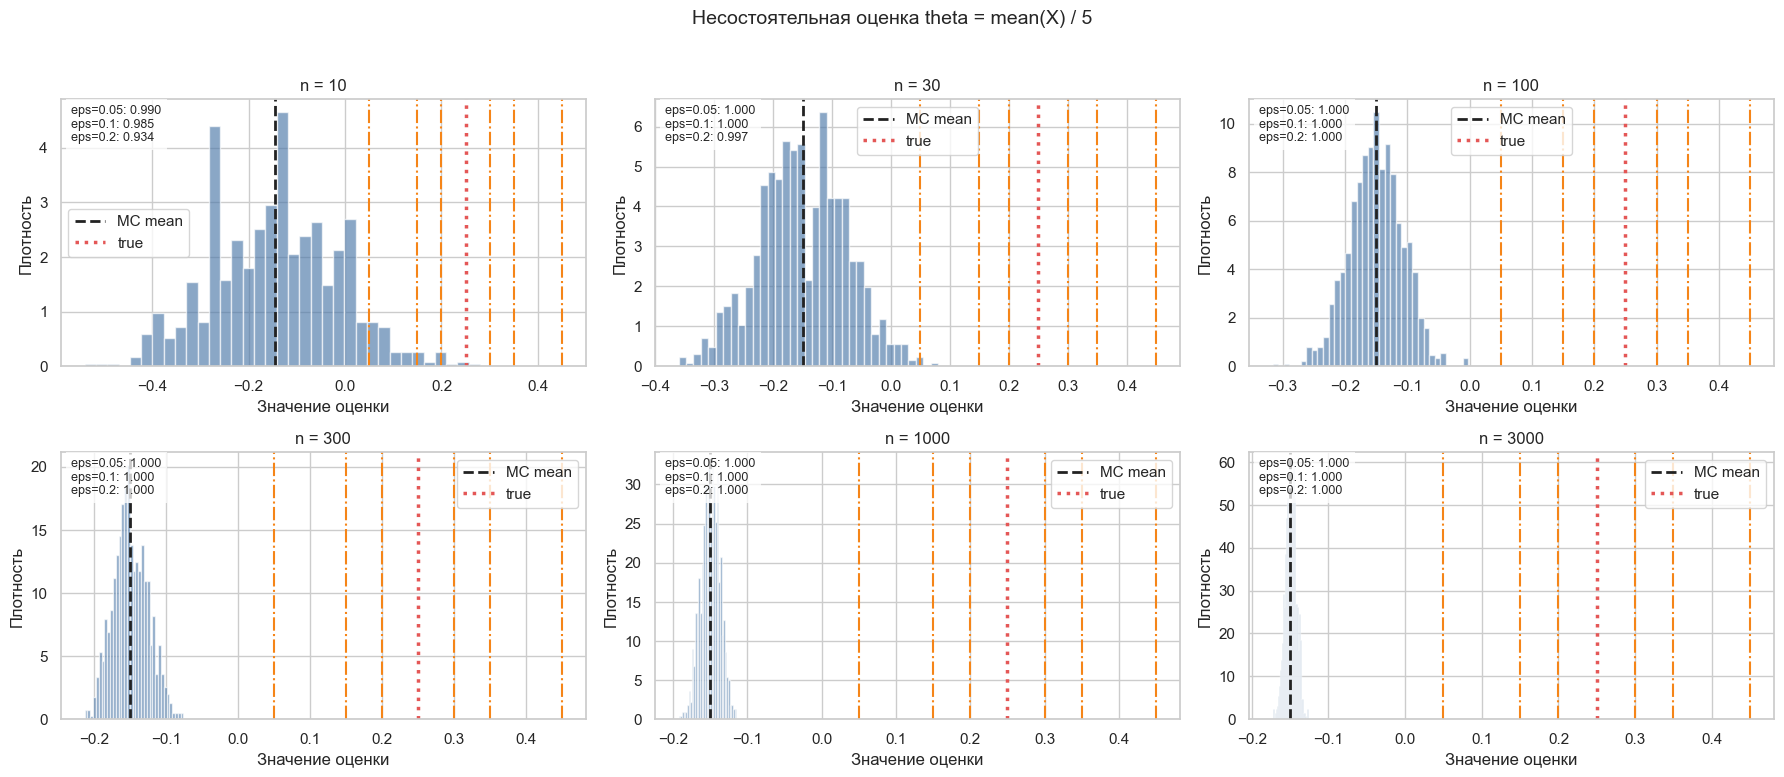

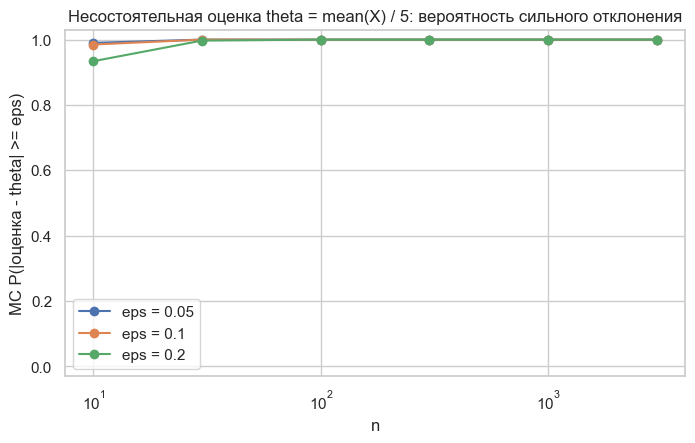

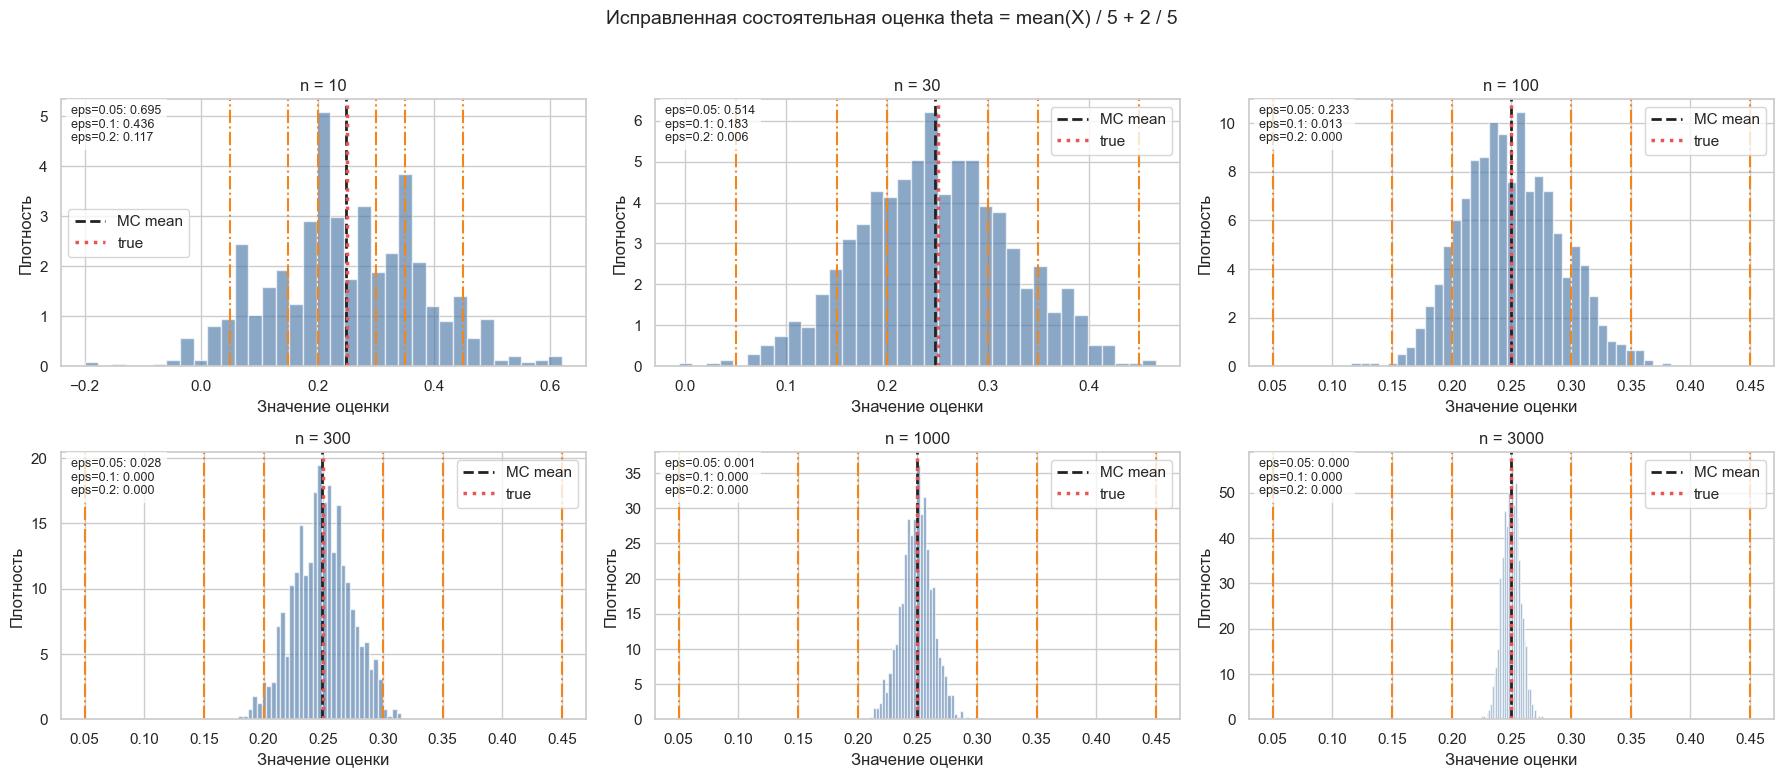

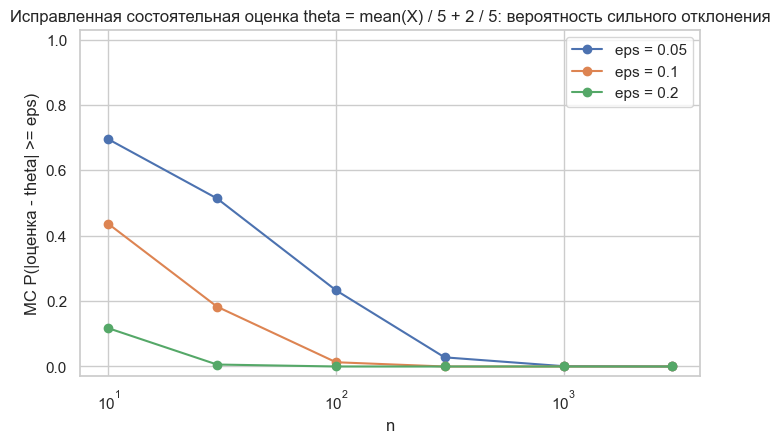

In [100]:
discrete_theta = 0.25

def discrete_generator(n: int) -> np.ndarray:
    return np.random.choice(
        [-3, 0, 2],
        size=n,
        p=[2 / 3 - discrete_theta, 1 / 3, discrete_theta]
    )

bad_discrete_estimator = lambda x: np.mean(x) / 5
good_discrete_estimator = lambda x: np.mean(x) / 5 + 2 / 5

plot_consistency_check(
    discrete_generator,
    bad_discrete_estimator,
    consistency_sample_sizes,
    true_theta=discrete_theta,
    epsilons=[0.05, 0.1, 0.2],
    repeats=1000,
    title='Несостоятельная оценка theta = mean(X) / 5'
)

plot_consistency_check(
    discrete_generator,
    good_discrete_estimator,
    consistency_sample_sizes,
    true_theta=discrete_theta,
    epsilons=[0.05, 0.1, 0.2],
    repeats=1000,
    title='Исправленная состоятельная оценка theta = mean(X) / 5 + 2 / 5'
)


Видим, что сначала оценка действительно несостоятельна: это хорошо видно по графику тк вероятность получить большую разность по модулю стремится к 1

После исправления же, все как раньше: разность стремится к 0 при росте n

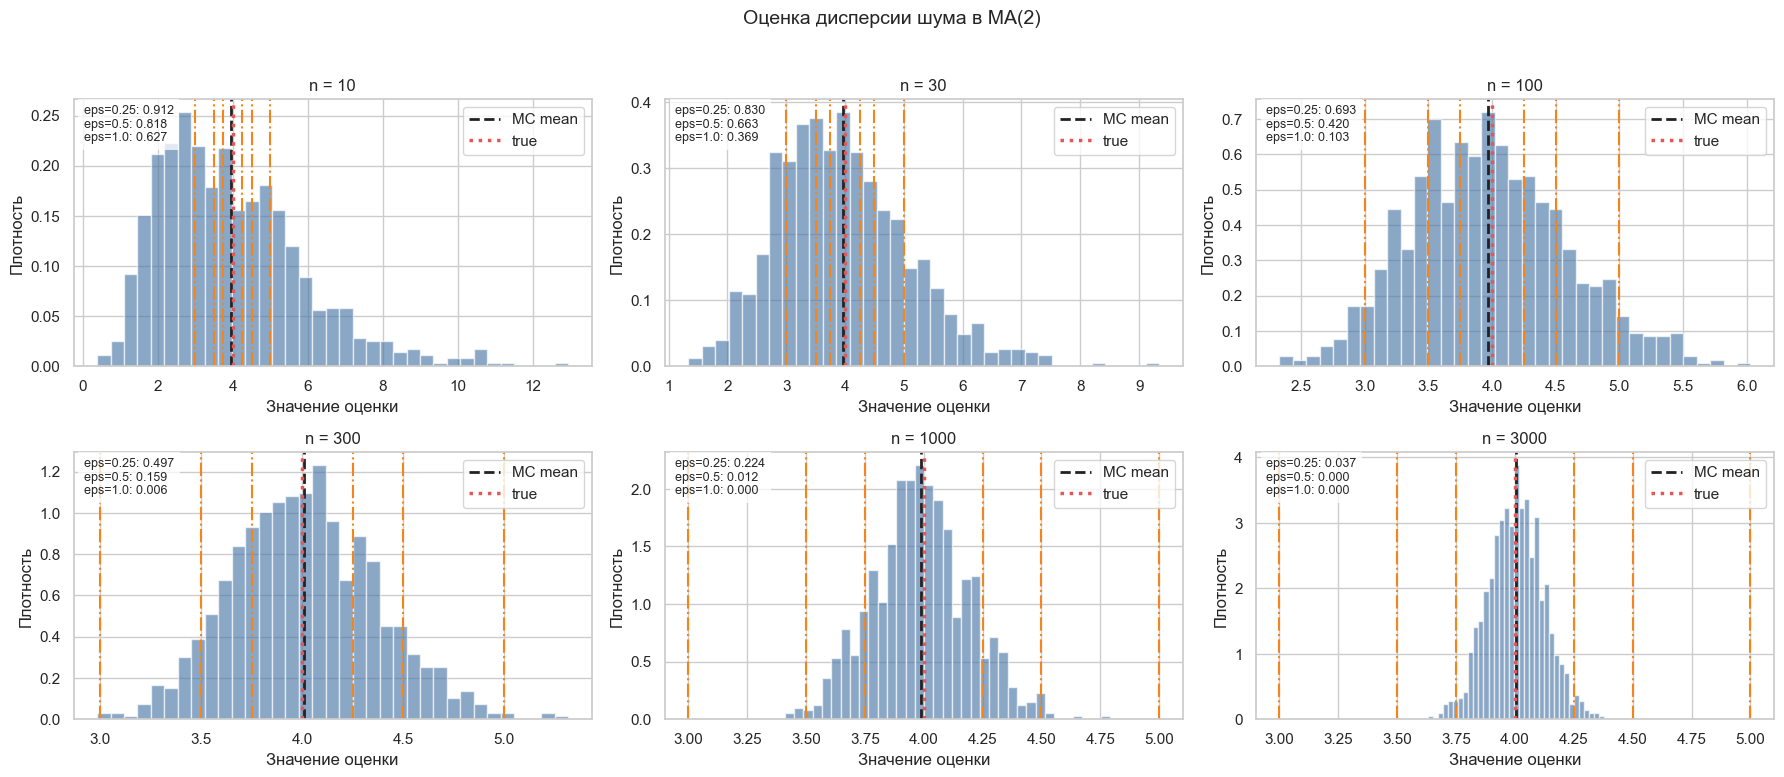

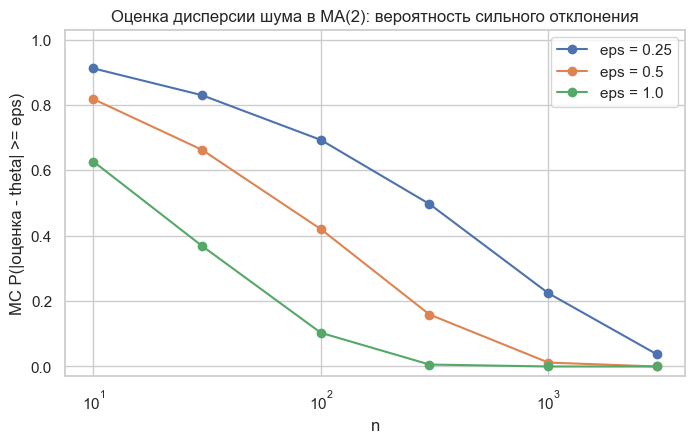

In [101]:
ma_mu = 3
beta_1 = 0.7
beta_2 = -0.4
sigma_eps = 2
true_noise_variance = sigma_eps ** 2


def ma2_generator(n: int) -> np.ndarray:
    eps = np.random.normal(loc=0, scale=sigma_eps, size=n + 2)
    return ma_mu + eps[2:] + beta_1 * eps[1:-1] + beta_2 * eps[:-2]


def ma2_noise_variance_estimator(x_values: np.ndarray) -> float:
    variance_x = np.mean((x_values - ma_mu) ** 2)
    return variance_x / (1 + beta_1 ** 2 + beta_2 ** 2)

plot_consistency_check(
    ma2_generator,
    ma2_noise_variance_estimator,
    consistency_sample_sizes,
    true_theta=true_noise_variance,
    epsilons=[0.25, 0.5, 1.0],
    repeats=1000,
    title='Оценка дисперсии шума в MA(2)'
)


Опять же, видим, что оценка действительно состоятельна: при росте n распределение оценок все более и более съезжает к истинному значению (а вероятность получить большую по модулю разность падает до 0)

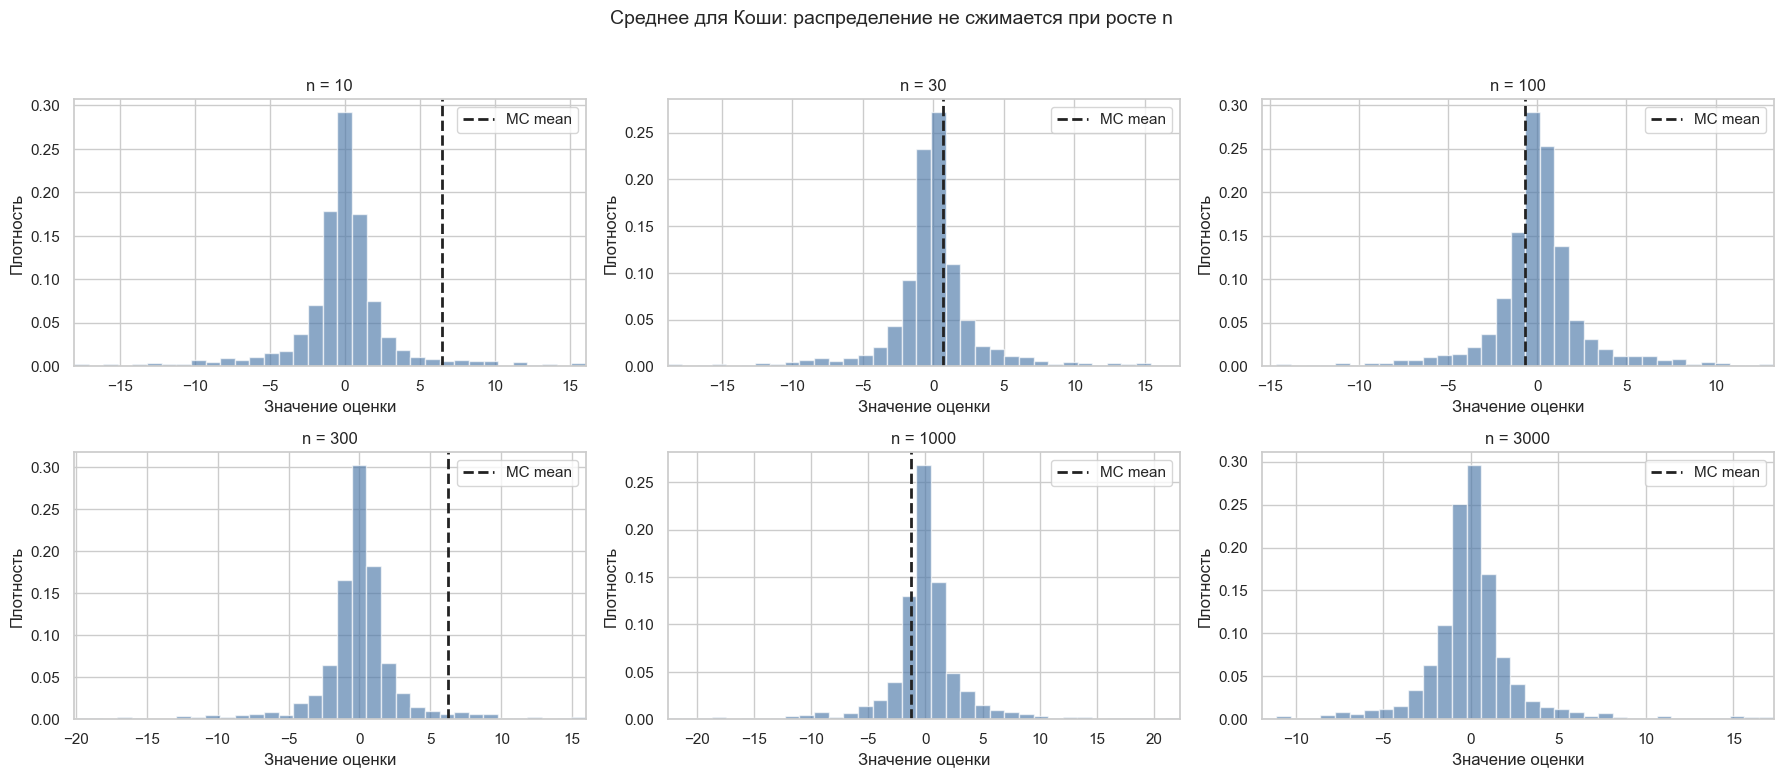

In [102]:
cauchy_sample_sizes = [10, 30, 100, 300, 1000, 3000]
cauchy_generator = lambda n: stats.cauchy.rvs(size=n)
cauchy_mean = lambda x: np.mean(x)

plot_consistency_check(
    cauchy_generator,
    cauchy_mean,
    cauchy_sample_sizes,
    true_theta=None,
    epsilons=None,
    repeats=2000,
    title='Среднее для Коши: распределение не сжимается при росте n',
    trim=(0.02, 0.98)
)


Интересно, что при росте n оценка не становится стабильнее

Обычно мы ждем, что при росте n – \bar{X} \to E(X), но здесь это не так

## Доверительные интервалы

<span style="color: #AC19C9;"> Доверительные интервалы в этом блоке необходимо отрисовывать самостоятельно, использовать встроенные в seaborn и другие библиотеки функции запрещено.</span>

### Разработка графика


Здесь нам снова необходимо продемонстрировать определение:

$\text{CI}_{1 - \alpha}(\theta) = [L; U]$, где $\theta$ - параметр распределения Х, а L и U это функции от выборки из Х $L(X_1, \dotso, X_n)$, $U(X_1, \dotso, X_n)$. Эти L и U такие, что $P(L(X_1, \dotso, X_n) \leq \theta \leq U(X_1, \dotso, X_n)) = 1 - \alpha$, где вероятность рассматривается относительно L и U, а значит, относительно выборок, которые их формируют. Иначе говоря, "вероятность того, что нам попадется выборка, формирующая границы интервала L и U так, что интервал [L; U] накроет параметр $\theta$, должна быть хотя бы $1 - \alpha$, в том смысле, что наше правило (функция) построения границ должно это гарантировать.

Хм, снова метод Монте-Карло на выручку!

Раз мы хотим показать вероятность события "интервал накрыл параметр", давайте получим B выборок по Монте-Карло, для каждой из них посчитаем границы по заданному правилу, и для каждой пары проверим, накрыла ли она параметр. Так мы получим долю выборок, для которых это случилось, то есть Монте-Карло оценку вероятности!

Но как нам отобразить эти доверительные интервалы по каждой выборке?

**Попробуем воспользоваться двумя подходами:**

*Первый:* отложим истинный параметр как линию, перпендикулярную оси значений параметра, а доверительные интервалы будем отражать перпендикулярно этой линии, по одному доверительному интервалу на каждой точке по второй оси, где отложен номер выборки, по которому CI построили. Чем-то это будет похоже на сосиски, которые проткнули шампуром в разных точках на их длине (при этом в какую-то долю сосисок шампуром не попадут.) Однако, если так сделать, то отследить глазами долю выборок, в которых такое произошло, будет очень тяжело, поскольку концы интервалов будут вечно сильно колебаться. <span style="color: #AC19C9;">Придумайте, как исправить эту визуальную проблему, базируясь на этом графике.</span>


*Второй:* нарисуем график эмпирических распределений левых и правых границ отдельно! На обоих графиках отложим по прямой, соответствующей истинному значению параметра. Поясните, как по таким графикам считать долю выборок, CI по которым накрыли / не накрыли параметр. Автоматически выводите необходимые расчетные значения оценок вероятностей в легендах обоих графиков распределений.


<span style="color: #AC19C9;">
Это идеи графиков 1 и 2. Имплементируйте и отрисовывайте оба.
</span>

Расширим нашу демонстрацию: добавим изменение доверительного интервала при росте размера выборки n:

Мы хотим показать динамику при большом числе различных n, поэтому просто дублировать графики для ресэмплов разных размеров не очень эффективно. Поэтому предлагается отобразить график длины доверительного интервала в зависимости от размера выборки, и график оценок вероятностей попасть в наш доверительный интервал (график, описывающий одну такую, мы выводили выше). 

<span style="color: #AC19C9;">
Это идея графика 3. Имплементируйте и используйте его.
</span>

<span style="color: #AC19C9;">
Всегда ли есть смысл рассчитывать длину интервала как среднюю по длинам интервалов на отдельных выборках размера n; всегда ли это бессмысленно? Каким должен быть график оценок вероятностей в зависимости от n при демонстрации корректного при любой n доверительного интервала?
</span>


### Применение для конкретных оценок


#### Асимпт-нормальный доверительный интервал для среднего

Пусть $(X_1 \dotso X_n)$ - i. i. d. выборка из экспоненциального распределения $Exp(\lambda)$.

<span style="color: #AC19C9;">Выразите классический доверительный интервал для среднего, опираясь на ЦПТ. Отобразите эксперименты для него на системе графиков. 
Что вы наблюдаете на графике оценок вероятностей, почему это происходит? Какого характера проблему вы наблюдаете: занижение или завышение длины доверительного интервала?
</span>



#### Бутстрап доверительный интервал для медианы

Пусть $(X_1 \dotso X_n)$ - i. i. d. выборка из биномиального распределения $Bin(p, 10)$. 

<span style="color: #AC19C9;">
Напишите алгоритм для получения доверительного интервала для медианы при помощи бутстрап-метода поверх данной выборки. 
</span> Обратите внимание, что нужно использовать только информацию из одной конкретной выборки, несмотря на то, что сэмплируем из исходного распределения мы их целых B штук; иначе мы с вами изучали бы не бутстрап-процедуру, а нечто другое.


<span style="color: #AC19C9;"> Отобразите результаты экспериментов над алгоритмом для выборок с p = 0.1, p=0.5 и p=0.9. Что вы наблюдаете, почему? Какого характера проблему вы наблюдаете: занижение или завышение длины доверительного интервала? </span> 


#### Асимпт-нормальный доверительный интервал для доли на краях интервала


Пусть $(X_1 \dotso X_n)$ - i. i. d. выборка из распределения Бернулли $Be(p)$. 

<span style="color: #AC19C9;">
Воспользуйтесь первым пунктом, а также возможно трюком с оценкой дисперсии Бернулли, и выразите доверительный интервал для доли p как среднего, опираясь на ЦПТ. Отобразите результаты экспериментов над правилом для выборок с p = 0.1, p=0.5 и p=0.9. Что вы наблюдаете, почему? Какого характера проблему вы наблюдаете: занижение или завышение длины доверительного интервала?
</span> 







In [103]:
def simulate_cis(
    sample_generator: Callable[[int], np.ndarray],
    ci_func: Callable[[np.ndarray], np.ndarray],
    n: int,
    *,
    true_theta: float,
    repeats: int = 1000
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    intervals = []
    for _ in range(repeats):
        sample = sample_generator(n)
        intervals.append(ci_func(sample))

    intervals = np.asarray(intervals, dtype=float)
    good_rows = np.isfinite(intervals).all(axis=1)
    intervals = intervals[good_rows]
    covered = (intervals[:, 0] <= true_theta) & (true_theta <= intervals[:, 1])
    lengths = intervals[:, 1] - intervals[:, 0]
    return intervals, covered, lengths


def plot_ci_intervals(
    intervals: np.ndarray,
    covered: np.ndarray,
    *,
    true_theta: float,
    title: str = '',
    max_intervals: int = 80,
    ax: plt.Axes | None = None
) -> plt.Axes:
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 6))

    centers = intervals.mean(axis=1)
    order = np.argsort(centers)
    if len(order) > max_intervals:
        order = order[np.linspace(0, len(order) - 1, max_intervals).astype(int)]

    shown_intervals = intervals[order]
    shown_covered = covered[order]
    y_values = np.arange(len(shown_intervals))
    colors = np.where(shown_covered, '#4c78a8', '#e45756')

    for y_value, interval, color in zip(y_values, shown_intervals, colors):
        ax.hlines(y_value, interval[0], interval[1], color=color, linewidth=2)

    ax.axvline(true_theta, color='#222222', linestyle='--', linewidth=2, label='true theta')
    ax.set_title(f'{title}\ncoverage = {covered.mean():.3f}')
    ax.set_xlabel('Значение параметра')
    ax.set_ylabel('Номер интервала после сортировки')
    ax.legend()
    return ax


def plot_ci_bound_distributions(
    intervals: np.ndarray,
    covered: np.ndarray,
    *,
    true_theta: float,
    title: str = '',
    bins: int = 35
) -> None:
    left_ok = np.mean(intervals[:, 0] <= true_theta)
    right_ok = np.mean(true_theta <= intervals[:, 1])

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].hist(intervals[:, 0], bins=bins, density=True, alpha=0.65, color='#4c78a8')
    axes[0].axvline(true_theta, color='#e45756', linestyle=':', linewidth=2.5)
    axes[0].set_title(f'Левые границы, P(L <= theta) = {left_ok:.3f}')
    axes[0].set_xlabel('L')
    axes[0].set_ylabel('Плотность')

    axes[1].hist(intervals[:, 1], bins=bins, density=True, alpha=0.65, color='#54a24b')
    axes[1].axvline(true_theta, color='#e45756', linestyle=':', linewidth=2.5)
    axes[1].set_title(f'Правые границы, P(theta <= U) = {right_ok:.3f}')
    axes[1].set_xlabel('U')
    axes[1].set_ylabel('Плотность')

    fig.suptitle(f'{title}; coverage = {covered.mean():.3f}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_ci_experiment(
    sample_generator: Callable[[int], np.ndarray],
    ci_func: Callable[[np.ndarray], np.ndarray],
    n: int,
    *,
    true_theta: float,
    repeats: int = 1000,
    title: str = ''
) -> None:
    intervals, covered, _ = simulate_cis(
        sample_generator,
        ci_func,
        n,
        true_theta=true_theta,
        repeats=repeats
    )
    plot_ci_intervals(
        intervals,
        covered,
        true_theta=true_theta,
        title=title
    )
    plt.show()
    plot_ci_bound_distributions(
        intervals,
        covered,
        true_theta=true_theta,
        title=title
    )


def plot_ci_by_n(
    sample_generator: Callable[[int], np.ndarray],
    ci_func: Callable[[np.ndarray], np.ndarray],
    sample_sizes: list[int],
    *,
    true_theta: float,
    repeats: int = 1000,
    target_coverage: float = 0.95,
    title: str = ''
) -> pd.DataFrame:
    rows = []
    for n in sample_sizes:
        intervals, covered, lengths = simulate_cis(
            sample_generator,
            ci_func,
            n,
            true_theta=true_theta,
            repeats=repeats
        )
        rows.append({
            'n': n,
            'coverage': np.mean(covered),
            'mean_length': np.mean(lengths),
            'median_length': np.median(lengths)
        })

    table = pd.DataFrame(rows)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(table['n'], table['mean_length'], marker='o', label='mean length')
    axes[0].plot(table['n'], table['median_length'], marker='o', label='median length')
    axes[0].set_xscale('log')
    axes[0].set_title('Длина интервала')
    axes[0].set_xlabel('n')
    axes[0].set_ylabel('Длина')
    axes[0].legend()

    axes[1].plot(table['n'], table['coverage'], marker='o', color='#4c78a8')
    axes[1].axhline(target_coverage, color='#e45756', linestyle=':', linewidth=2, label='целевое накрытие')
    axes[1].set_xscale('log')
    axes[1].set_ylim(-0.03, 1.03)
    axes[1].set_title('MC-вероятность накрытия')
    axes[1].set_xlabel('n')
    axes[1].set_ylabel('Coverage')
    axes[1].legend()

    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    return table


def normal_mean_ci(
    data: np.ndarray,
    *,
    alpha: float = 0.05
) -> np.ndarray:
    z_value = stats.norm.ppf(1 - alpha / 2)
    center = np.mean(data)
    se = np.std(data, ddof=1) / np.sqrt(len(data))
    return np.array([center - z_value * se, center + z_value * se])


def bootstrap_percentile_ci(
    data: np.ndarray,
    statistic: Callable[[np.ndarray], float],
    *,
    alpha: float = 0.05,
    bootstrap_repeats: int = 500
) -> np.ndarray:
    bootstrap_values = []
    for _ in range(bootstrap_repeats):
        bootstrap_sample = np.random.choice(data, size=len(data), replace=True)
        bootstrap_values.append(statistic(bootstrap_sample))
    return np.quantile(bootstrap_values, [alpha / 2, 1 - alpha / 2])


def bernoulli_wald_ci(
    data: np.ndarray,
    *,
    alpha: float = 0.05
) -> np.ndarray:
    z_value = stats.norm.ppf(1 - alpha / 2)
    p_hat = np.mean(data)
    se = np.sqrt(p_hat * (1 - p_hat) / len(data))
    return np.array([p_hat - z_value * se, p_hat + z_value * se])


 1. $Exp(\lambda)$
$$E(\bar{X}) = E(X_i) = \frac{1}{\lambda}; \space D(\bar{X}) = \frac{D(X_i)}{n}  $$
$$\text{По ЦПТ}: \space \bar{X}\sim N(\frac{1}{\lambda},\space \frac{D(X_i)}{n})  $$
 $$\text{Тогда можем построить такой CI}: \space $$
 $$[\bar{X} - z_{1-\alpha/2}\cdot se(\bar{X}), \bar{X} + z_{1-\alpha/2}\cdot se(\bar{X})] = [\bar{X} - z_{1-\alpha/2}\cdot \sqrt{\frac{D(X_i)}{n}} , \bar{X} + z_{1-\alpha/2}\cdot \sqrt{\frac{D(X_i)}{n}}] = $$
 $$\text{Заменим дисперсию на оценку: }\space [\bar{X} - z_{1-\alpha/2}\cdot \sqrt{\frac{S^2}{n}} ,\space \bar{X} + z_{1-\alpha/2}\cdot \sqrt{\frac{S^2}{n}}]  $$

2. Be(p)
$$\hat{p} = \bar{X} \implies \hat{p} \sim N(p,\space \frac{p(1-p)}{n}) $$
$$\text{Строим такой CI: }\space [\hat{p} - z_{1-\alpha/2}\cdot \sqrt{\frac{D(X_i)}{n}} ,\space \hat{p} + z_{1-\alpha/2}\cdot \sqrt{\frac{D(X_i)}{n}}] $$
$$\text{Заменим дисперсию ее оценкой: }\space \hat{D}(X_i) = \hat{p}
(1-\hat{p}) $$
$$[\bar{X} - z_{1-\alpha/2}\cdot \sqrt{\frac{\hat{p}
(1-\hat{p})}{n}} , \bar{X} + z_{1-\alpha/2}\cdot \sqrt{\frac{\hat{p}
(1-\hat{p})}{n}}] $$

<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hs/zg26hl1x5_b6n1q580q7gpxc0000gn/T/ipykernel_24538/418138904.py:22: SyntaxWarning: invalid escape sequence '\l'
  title='exp(\lambda): как меняются длина и накрытие CI для среднего'


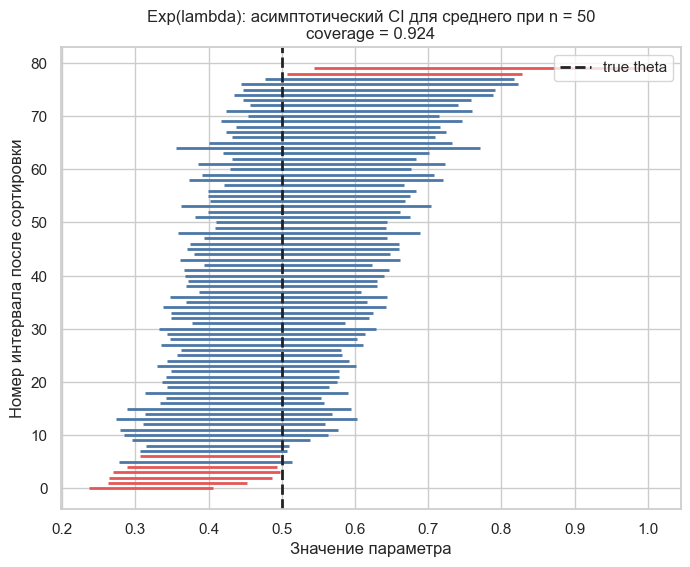

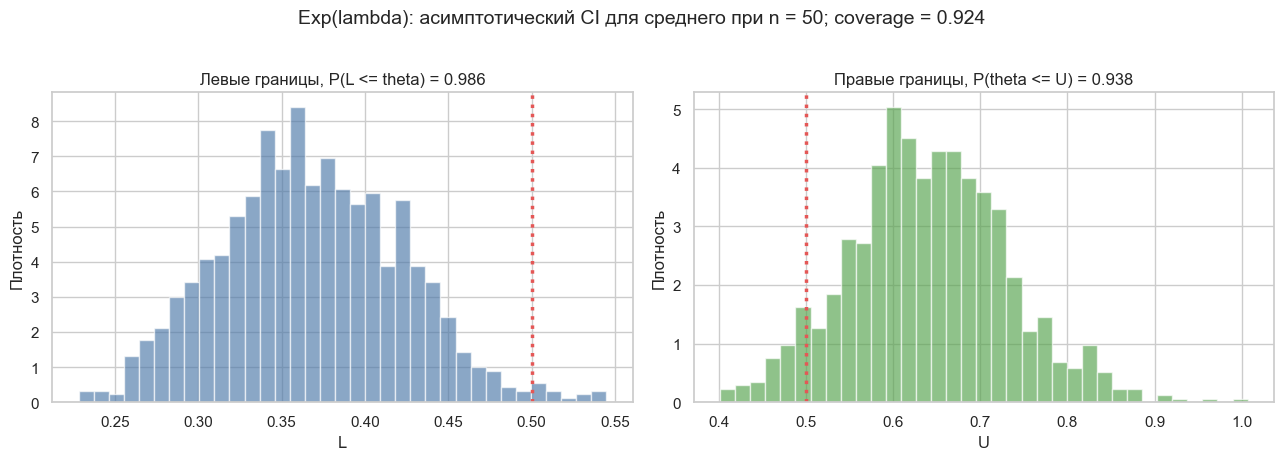

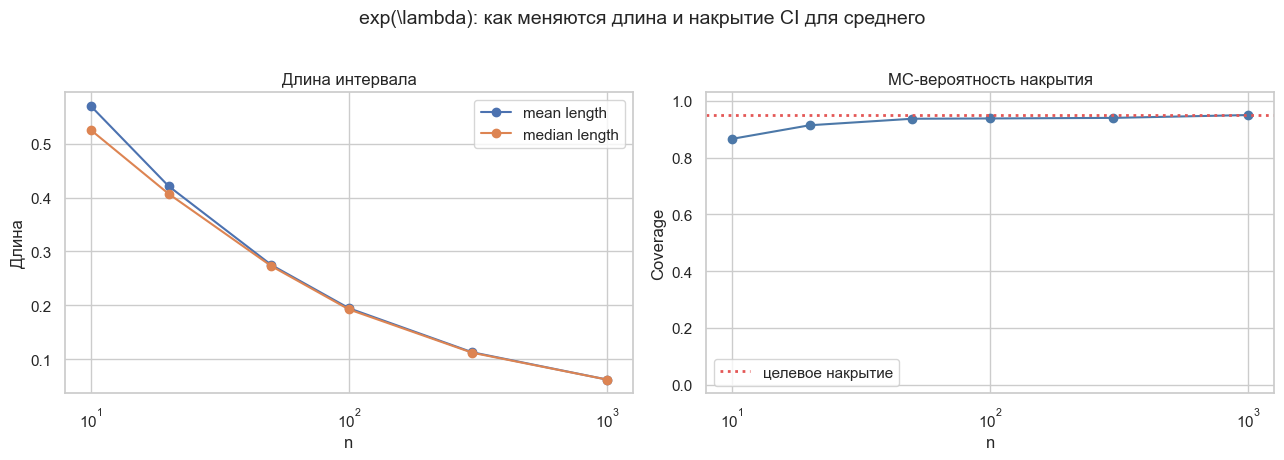

,n,coverage,mean_length,median_length
0,10,0.866,0.570334,0.525785
1,20,0.914,0.421603,0.407341
2,50,0.937,0.275103,0.272969
3,100,0.938,0.194562,0.192352
4,300,0.940,0.112777,0.111906
5,1000,0.950,0.061968,0.061906


In [122]:
ci_sample_sizes = [10, 20, 50, 100, 300, 1000]
exp_lambda = 2
exp_generator = lambda n: np.random.exponential(scale=1 / exp_lambda, size=n)
true_exp_mean = 1 / exp_lambda
exp_ci = lambda data: normal_mean_ci(data, alpha=0.05)

plot_ci_experiment(
    exp_generator,
    exp_ci,
    n=50,
    true_theta=true_exp_mean,
    repeats=1000,
    title='Exp(lambda): асимптотический CI для среднего при n = 50'
)

exp_ci_table = plot_ci_by_n(
    exp_generator,
    exp_ci,
    ci_sample_sizes,
    true_theta=true_exp_mean,
    repeats=1000,
    title='exp(\lambda): как меняются длина и накрытие CI для среднего'
)
exp_ci_table


Ну тут скорее мы видим занижение правой границы. Часть мы теряем, потому что истинное значение правее большого хвоста правой границы

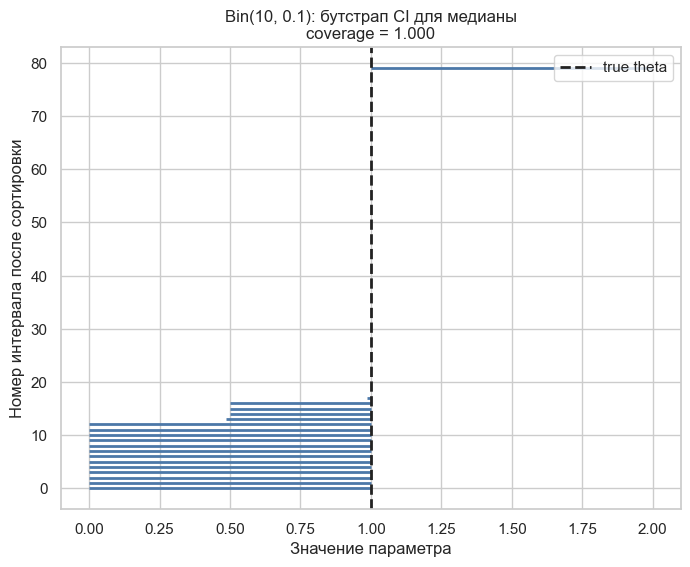

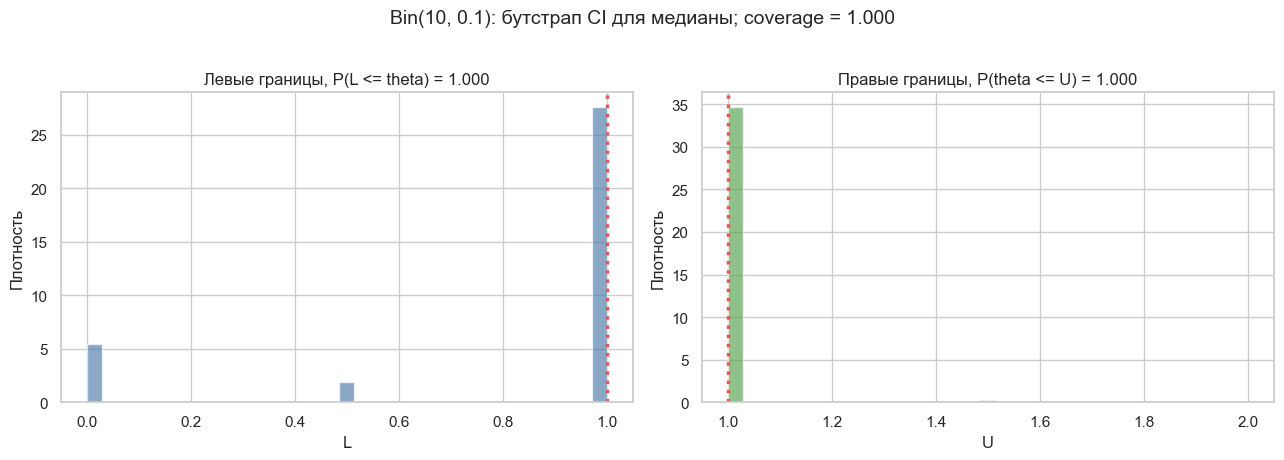

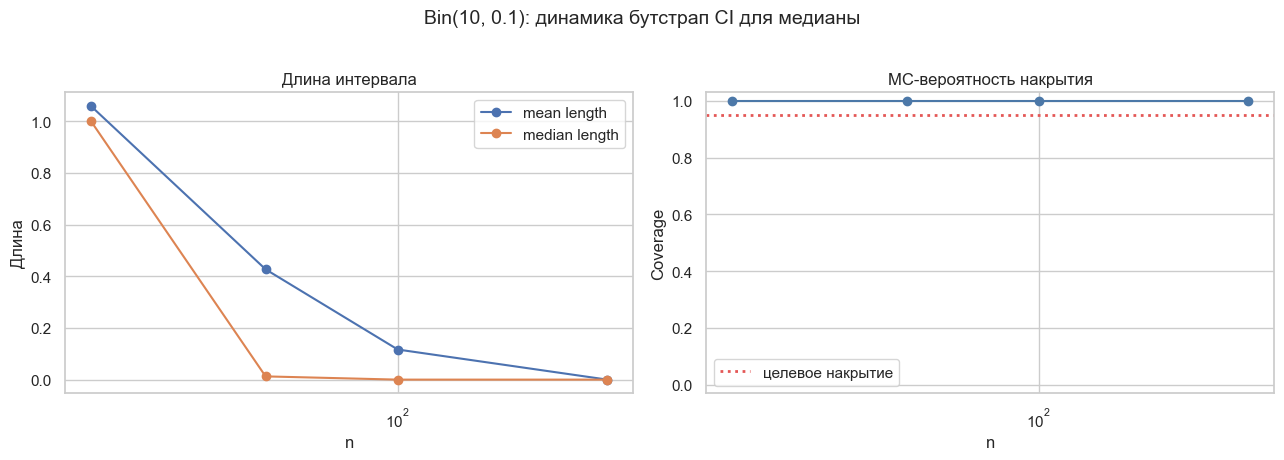

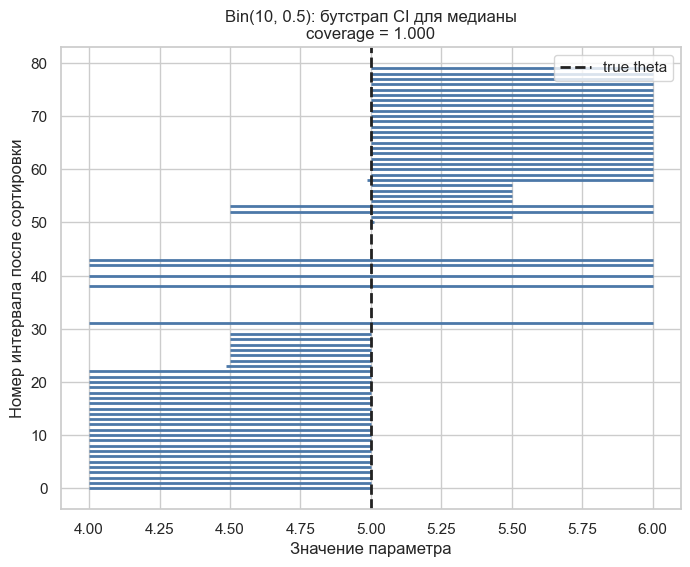

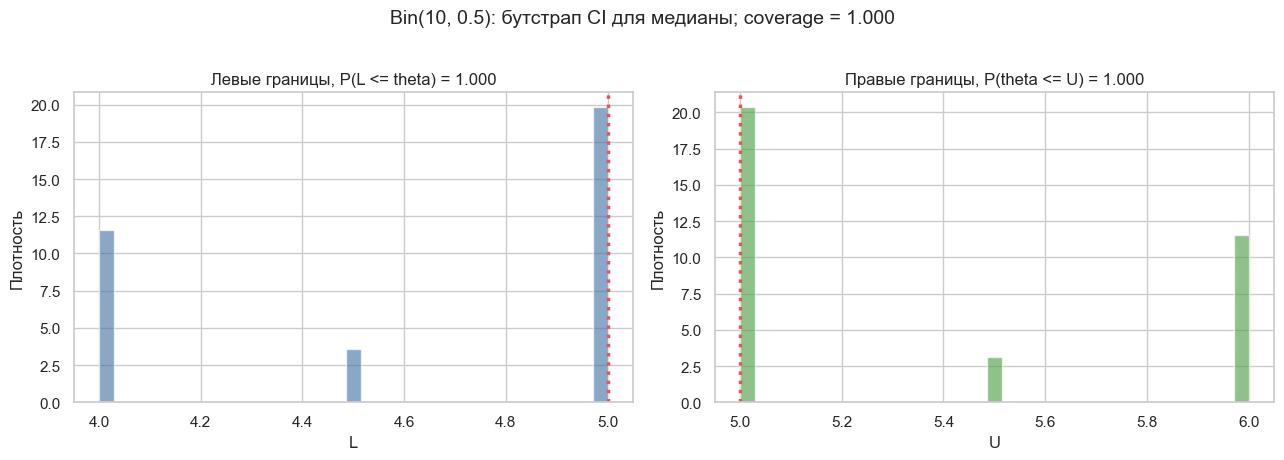

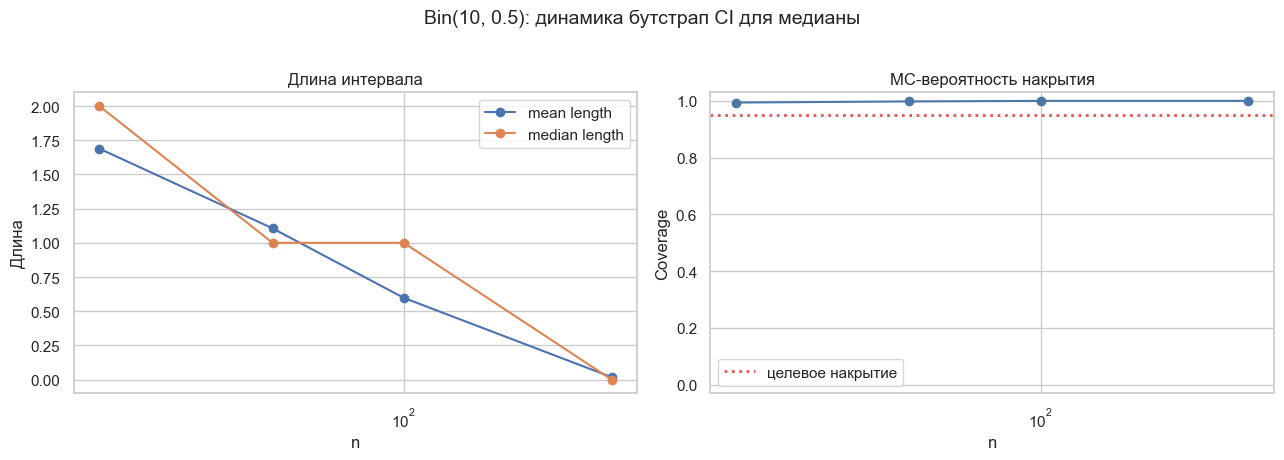

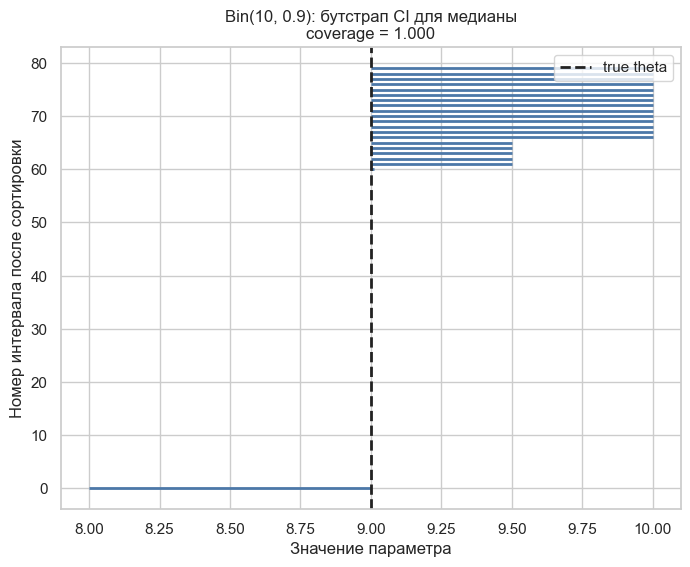

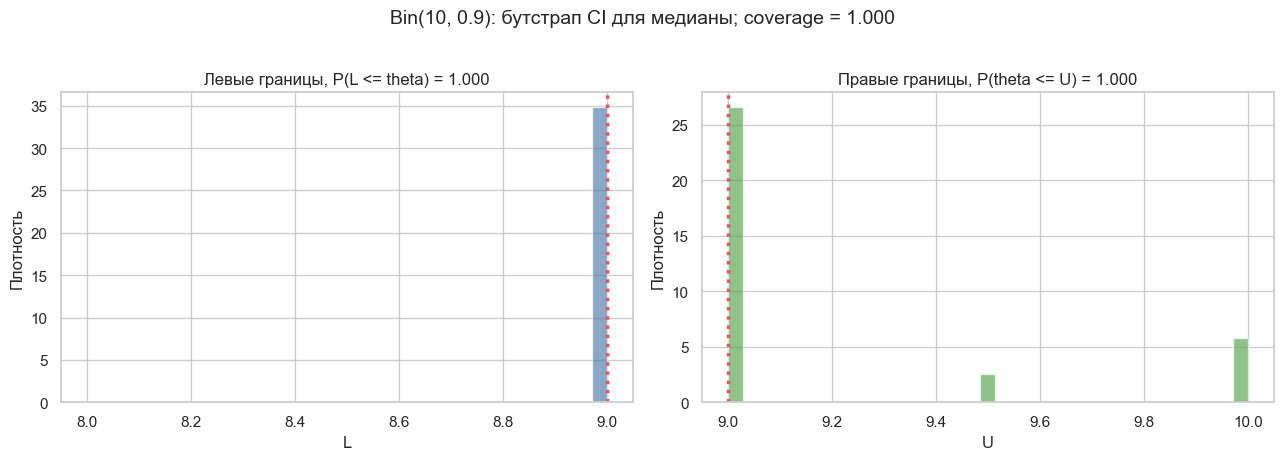

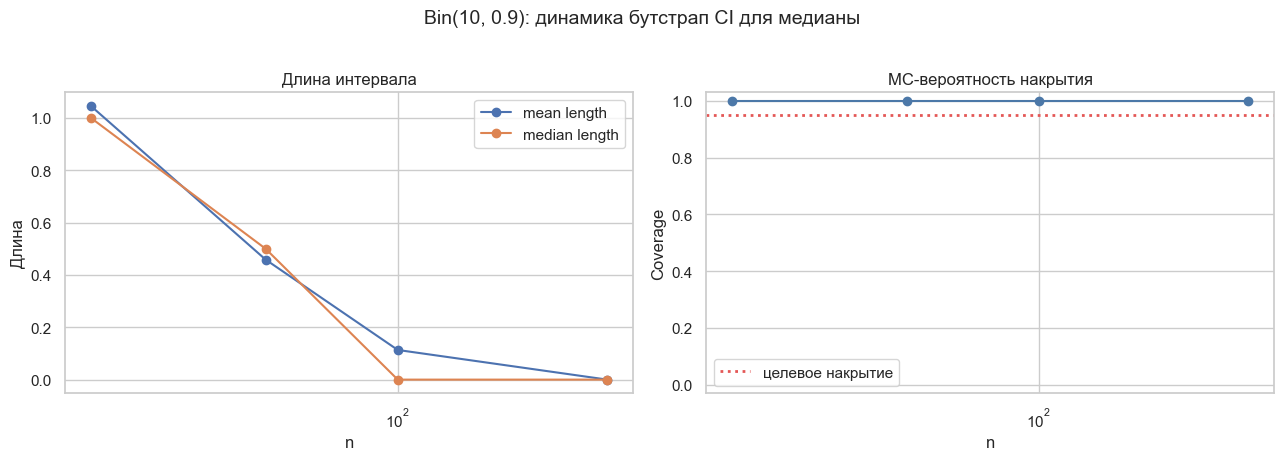

In [105]:
binomial_ci_sample_sizes = [20, 50, 100, 300]

for binomial_p in [0.1, 0.5, 0.9]:
    binomial_generator = lambda n, p=binomial_p: np.random.binomial(10, p, size=n)
    true_binomial_median = stats.binom.median(10, binomial_p)
    median_bootstrap_ci = lambda data: bootstrap_percentile_ci(
        data,
        np.median,
        alpha=0.05,
        bootstrap_repeats=400
    )

    plot_ci_experiment(
        binomial_generator,
        median_bootstrap_ci,
        n=80,
        true_theta=true_binomial_median,
        repeats=600,
        title=f'Bin(10, {binomial_p}): бутстрап CI для медианы'
    )

    plot_ci_by_n(
        binomial_generator,
        median_bootstrap_ci,
        binomial_ci_sample_sizes,
        true_theta=true_binomial_median,
        repeats=500,
        title=f'Bin(10, {binomial_p}): динамика бутстрап CI для медианы'
    )


Алгоритм:

- Есть одна исходная выборка
- Из нее много раз делаем бутстрап выборки
- Для каждой бутстрап выборки считаем медиану
- Берем квантили полученного распределения медиан

Видим, что у нас интервалы явно дискретные, а сама статистика меняется скачками

Тут скорее наблюдаем завышение границ

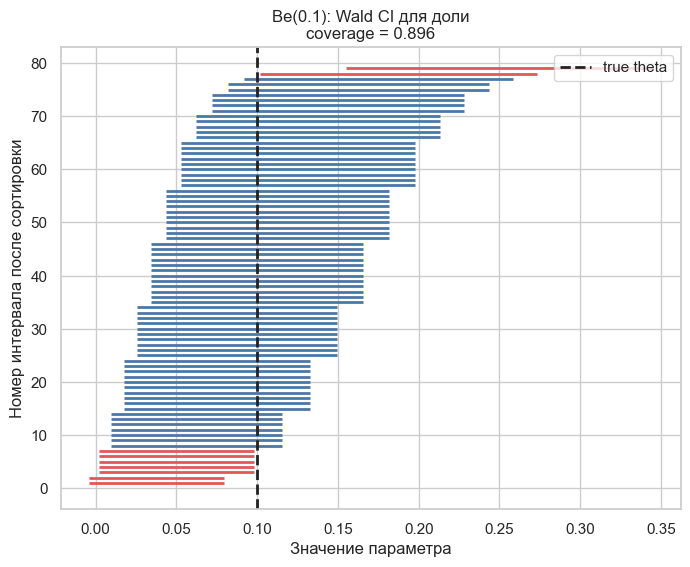

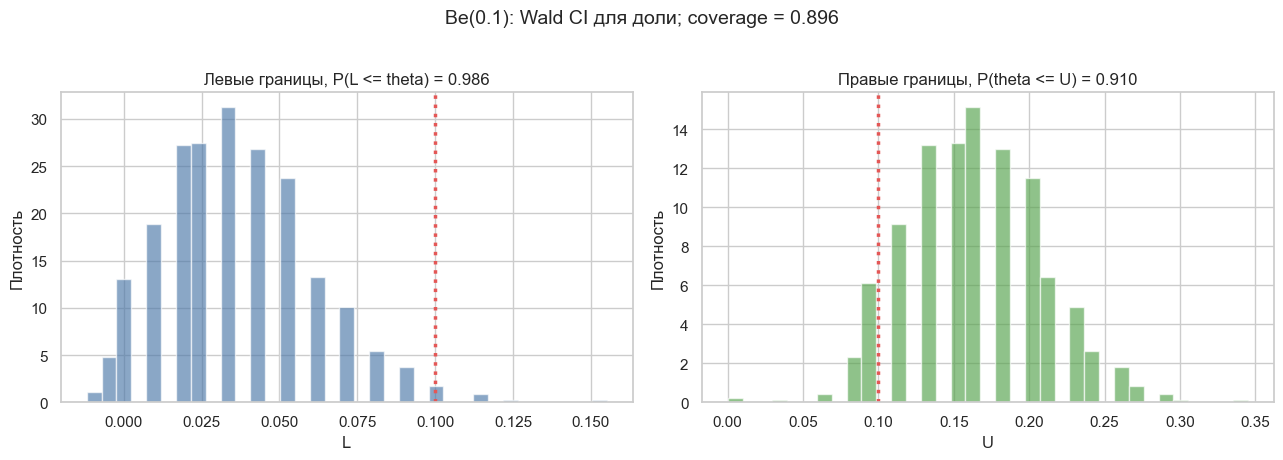

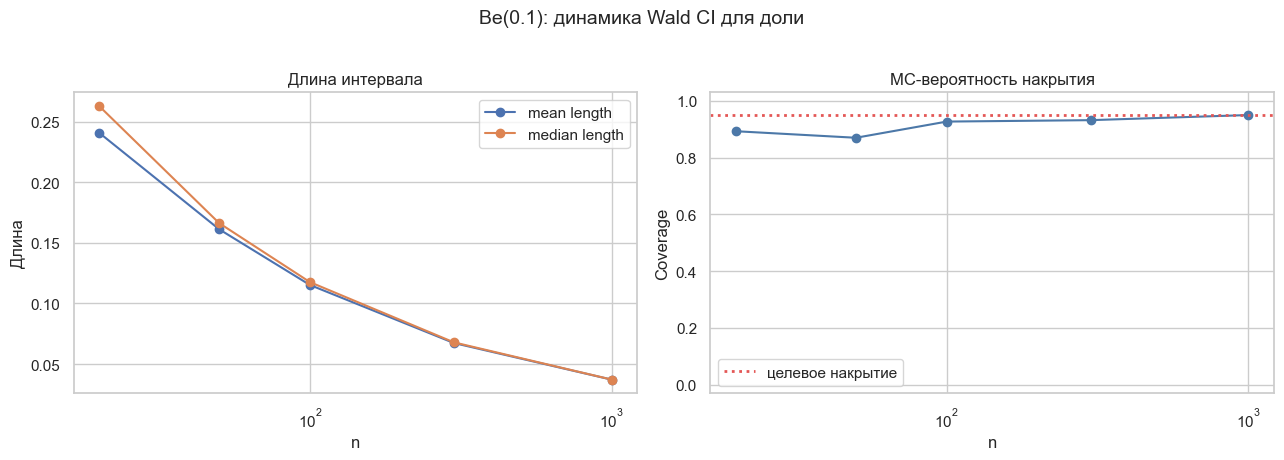

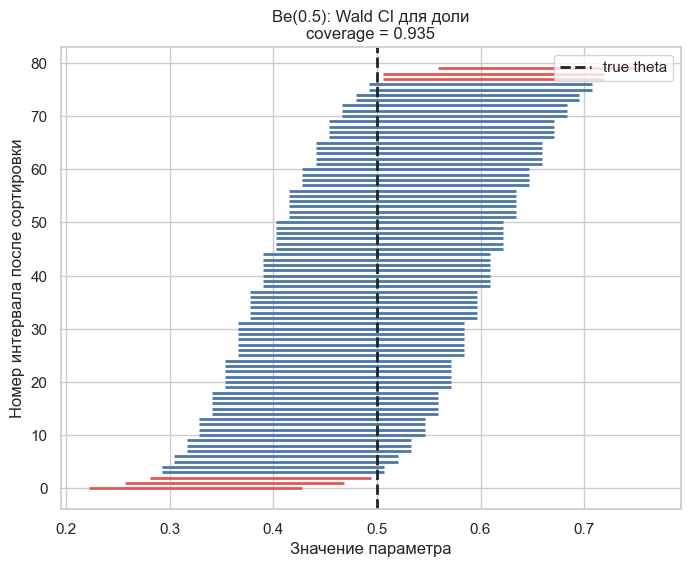

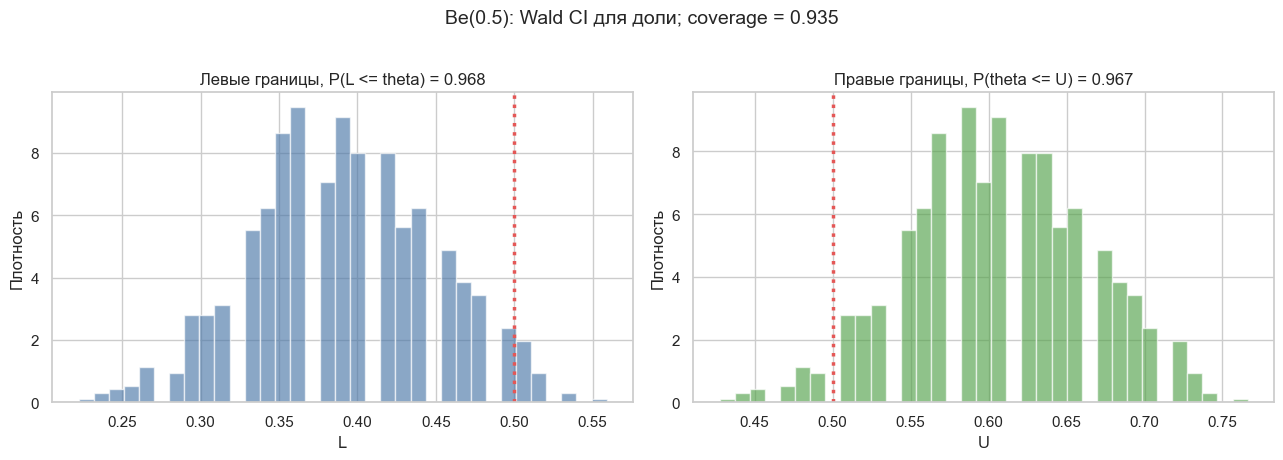

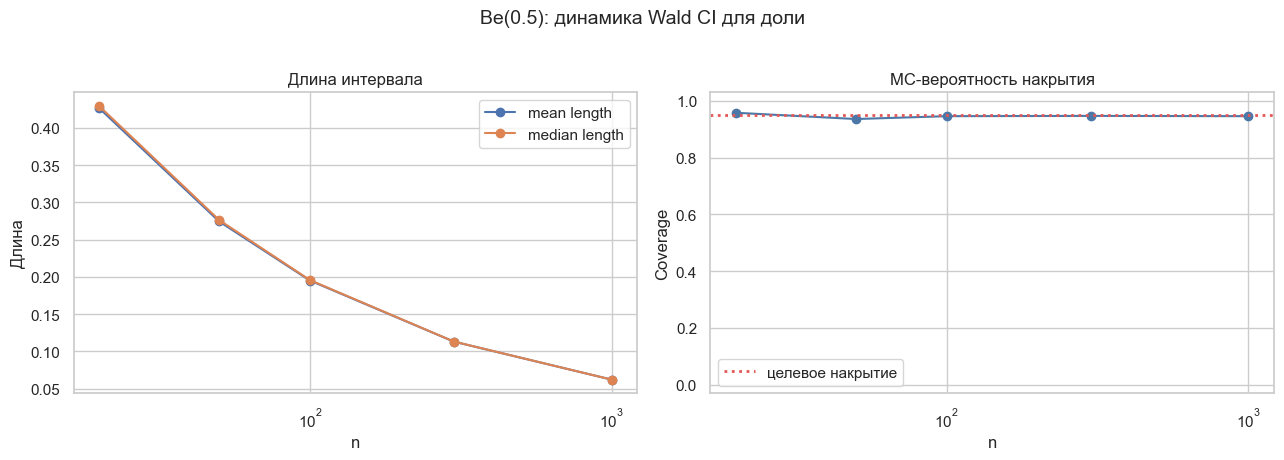

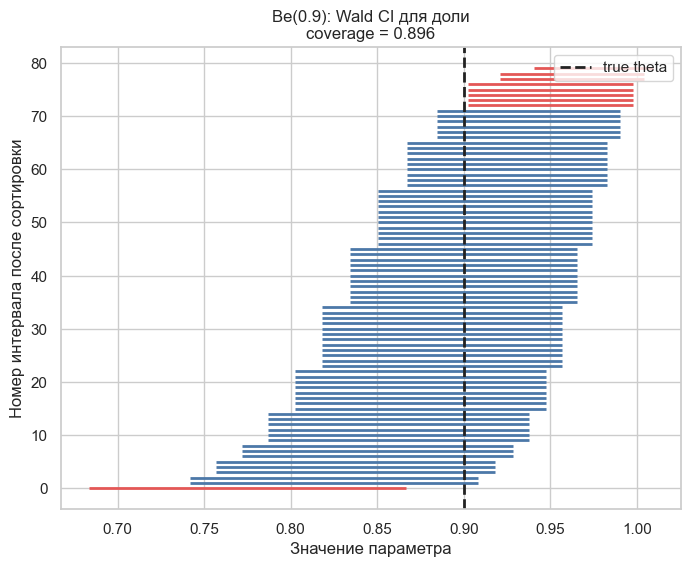

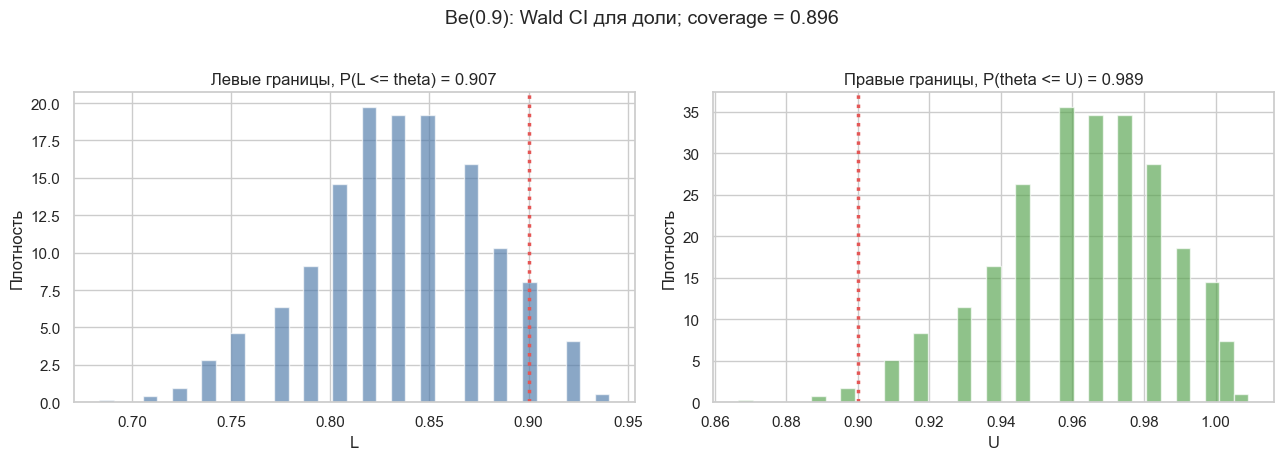

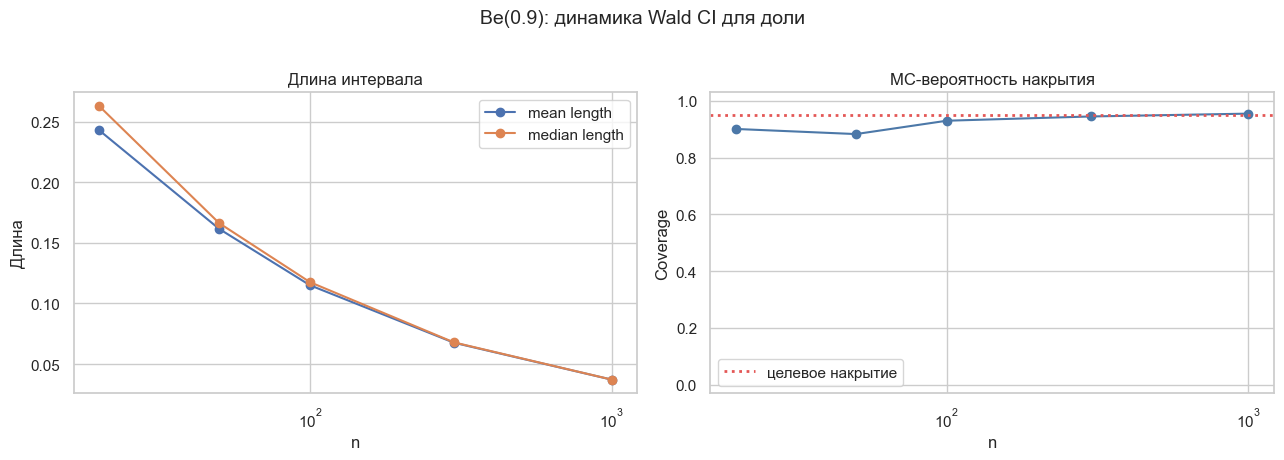

In [106]:
bernoulli_ci_sample_sizes = [20, 50, 100, 300, 1000]

for bernoulli_p in [0.1, 0.5, 0.9]:
    bernoulli_generator = lambda n, p=bernoulli_p: np.random.binomial(1, p, size=n)
    wald_ci = lambda data: bernoulli_wald_ci(data, alpha=0.05)

    plot_ci_experiment(
        bernoulli_generator,
        wald_ci,
        n=80,
        true_theta=bernoulli_p,
        repeats=1000,
        title=f'Be({bernoulli_p}): Wald CI для доли'
    )

    plot_ci_by_n(
        bernoulli_generator,
        wald_ci,
        bernoulli_ci_sample_sizes,
        true_theta=bernoulli_p,
        repeats=1000,
        title=f'Be({bernoulli_p}): динамика Wald CI для доли'
    )


Тут мы видим занижение интервала. Для каждой вероятности есть случаи, когда истинное значение не попадает в интервал. Самый стабильный наверное вышел p=0.5